In [1]:
from pathlib import Path
import json
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [2]:
PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

json_file = RAW_DATA_DIR / "games.json"

with open(json_file, "r", encoding="utf-8") as f:
    games = json.load(f)

print(f"Loaded {len(games):,} games")

Loaded 135,140 games


In [3]:
records = []

for appid, game in games.items():
    row = game.copy()
    row["appid"] = int(appid)
    records.append(row)

df = pd.DataFrame(records)

print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (135140, 43)


,name,release_date,required_age,price,dlc_count,detailed_description,about_the_game,short_description,reviews,header_image,...,negative,estimated_owners,average_playtime_forever,average_playtime_2weeks,median_playtime_forever,median_playtime_2weeks,discount,peak_ccu,tags,appid
0,Black Dragon Mage Playtest,"Aug 1, 2023",0,0.00,0,,,,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 0,0,0,0,0,0,0,[],2539430
1,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0,5.24,0,"Springtime, April: when the cherry trees come ...","Springtime, April: when the cherry trees come ...","Spring has come, and our protagonist, Yukinari...",,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,8,0,8,0,65,0,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",496350
2,Mystery Solitaire The Black Raven,"May 6, 2019",0,4.99,0,"Immerse yourself in the most beloved, mystical...","Immerse yourself in the most beloved, mystical...",Discover an entrancing and spectacular world!,,https://shared.akamai.steamstatic.com/store_it...,...,3,0 - 20000,0,0,0,0,0,0,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...",1034400
3,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0,8.99,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...","synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",Yuha! I'll start the broadcast! Hakko's extrem...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,1,[],3292190
4,Maze Quest VR,"Apr 24, 2025",0,4.99,0,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,Its not just a Maze; its a Quest! Enter the ca...,,https://shared.akamai.steamstatic.com/store_it...,...,0,0 - 20000,0,0,0,0,0,0,[],3631080


In [4]:
df["release_date"] = pd.to_datetime(
    df["release_date"],
    errors="coerce"
)

df["release_year"] = (
    df["release_date"]
    .dt.year
    .astype("Int64")
)

df[
    [
        "appid",
        "name",
        "release_date",
        "release_year"
    ]
].head()

,appid,name,release_date,release_year
0,2539430,Black Dragon Mage Playtest,2023-08-01,2023
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,2019
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024
4,3631080,Maze Quest VR,2025-04-24,2025


In [5]:
numeric_columns = [
    "positive",
    "negative",
    "price"
]

for column in numeric_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    ).fillna(0)

df["positive"] = df["positive"].clip(lower=0)
df["negative"] = df["negative"].clip(lower=0)
df["price"] = df["price"].clip(lower=0)

In [6]:
REVIEW_MULTIPLIER = 45

df["total_reviews"] = (
    df["positive"]
    + df["negative"]
)

df["estimated_copies"] = (
    df["total_reviews"]
    * REVIEW_MULTIPLIER
)

df["estimated_revenue"] = (
    df["estimated_copies"]
    * df["price"]
)

df[
    [
        "name",
        "release_year",
        "positive",
        "negative",
        "total_reviews",
        "price",
        "estimated_revenue"
    ]
].head()

,name,release_year,positive,negative,total_reviews,price,estimated_revenue
0,Black Dragon Mage Playtest,2023,0,0,0,0.00,0.0
1,Supipara - Chapter 1 Spring Has Come!,2016,252,3,255,5.24,60129.0
2,Mystery Solitaire The Black Raven,2019,21,3,24,4.99,5389.2
3,버튜버 파라노이아 - Vtuber Paranoia,2024,0,0,0,8.99,0.0
4,Maze Quest VR,2025,0,0,0,4.99,0.0


In [7]:
print(df["tags"].apply(type).value_counts(dropna=False))

df[
    [
        "name",
        "tags"
    ]
].head(10)

tags
<class 'dict'>    83376
<class 'list'>    51764
Name: count, dtype: int64


,name,tags
0,Black Dragon Mage Playtest,[]
1,Supipara - Chapter 1 Spring Has Come!,"{'Adventure': 27, 'Visual Novel': 19, 'Anime':..."
2,Mystery Solitaire The Black Raven,"{'Casual': 83, 'Card Game': 52, 'Solitaire': 4..."
3,버튜버 파라노이아 - Vtuber Paranoia,[]
4,Maze Quest VR,[]
5,Agony VR,[]
6,Armored Brigade II,"{'Simulation': 193, 'Strategy': 186, 'RTS': 16..."
7,Galacatraz: Eject Equip Escape,[]
8,Hepta Beats,"{'Precision Platformer': 52, 'Rhythm': 45, 'Mu..."
9,MUMBA IV: Egypt Jewels,"{'Casual': 64, 'Action': 51, 'Strategy': 42, '..."


In [8]:
def normalize_tags(value):
    """
    Convert a Steam tag field into a dictionary of:
        tag_name -> tag_weight

    Invalid and non-positive weights are removed.
    """

    if value is None:
        return {}

    if isinstance(value, float) and pd.isna(value):
        return {}

    if isinstance(value, dict):
        raw_tags = value

    elif isinstance(value, str):
        value = value.strip()

        if not value:
            return {}

        try:
            parsed = ast.literal_eval(value)
        except (ValueError, SyntaxError):
            return {}

        if isinstance(parsed, dict):
            raw_tags = parsed

        elif isinstance(parsed, list):
            raw_tags = {
                str(tag): 1
                for tag in parsed
            }

        else:
            return {}

    elif isinstance(value, list):
        raw_tags = {
            str(tag): 1
            for tag in value
        }

    else:
        return {}

    cleaned_tags = {}

    for tag, weight in raw_tags.items():
        tag = str(tag).strip()

        if not tag:
            continue

        try:
            weight = float(weight)
        except (TypeError, ValueError):
            continue

        if weight <= 0:
            continue

        cleaned_tags[tag] = weight

    return cleaned_tags

In [20]:
EXCLUDED_TAGS = {
    "Early Access"
}

df["tags_clean"] = df["tags"].apply(
    normalize_tags
)

df["tag_list"] = df["tags_clean"].apply(
    lambda tags: [
        tag
        for tag in tags.keys()
        if tag not in EXCLUDED_TAGS
    ]
)

df["tag_count"] = df["tag_list"].apply(len)

df[
    [
        "name",
        "tags_clean",
        "tag_list",
        "tag_count"
    ]
].head(10)

,name,tags_clean,tag_list,tag_count
0,Black Dragon Mage Playtest,{},[],0
1,Supipara - Chapter 1 Spring Has Come!,"{'Adventure': 27.0, 'Visual Novel': 19.0, 'Ani...","[Adventure, Visual Novel, Anime, Cute]",4
2,Mystery Solitaire The Black Raven,"{'Casual': 83.0, 'Card Game': 52.0, 'Solitaire...","[Casual, Card Game, Solitaire, Puzzle, Hidden ...",16
3,버튜버 파라노이아 - Vtuber Paranoia,{},[],0
4,Maze Quest VR,{},[],0
5,Agony VR,{},[],0
6,Armored Brigade II,"{'Simulation': 193.0, 'Strategy': 186.0, 'RTS'...","[Simulation, Strategy, RTS, Wargame, Grand Str...",18
7,Galacatraz: Eject Equip Escape,{},[],0
8,Hepta Beats,"{'Precision Platformer': 52.0, 'Rhythm': 45.0,...","[Precision Platformer, Rhythm, Music, Difficul...",12
9,MUMBA IV: Egypt Jewels,"{'Casual': 64.0, 'Action': 51.0, 'Strategy': 4...","[Casual, Action, Strategy, Puzzle, Match 3, Si...",7


In [21]:
START_YEAR = 2022
END_YEAR = 2025

MIN_REVENUE = 150_000
MAX_REVENUE = 800_000

revenue_band_games = df.loc[
    df["release_year"].between(
        START_YEAR,
        END_YEAR,
        inclusive="both"
    )
    & df["estimated_revenue"].between(
        MIN_REVENUE,
        MAX_REVENUE,
        inclusive="both"
    )
    & df["price"].gt(0)
    & df["tag_count"].gt(0)
].copy()

print(
    f"Games in revenue range "
    f"${MIN_REVENUE:,.0f}–${MAX_REVENUE:,.0f}: "
    f"{len(revenue_band_games):,}"
)

revenue_band_games[
    [
        "appid",
        "name",
        "release_year",
        "estimated_revenue",
        "tag_count",
        "tag_list"
    ]
].head()

Games in revenue range $150,000–$800,000: 1,805


,appid,name,release_year,estimated_revenue,tag_count,tag_list
6,1934300,Armored Brigade II,2025,210541.50,18,"[Simulation, Strategy, RTS, Wargame, Grand Str..."
84,2997980,Natsu no Sagashimono ~What We Found That Summer~,2024,420309.45,15,"[Sexual Content, Hentai, Mature, Nudity, Casua..."
181,2287970,Dungeon's Legion,2023,387117.90,13,"[RPG, Adventure, Sexual Content, Casual, Henta..."
216,2094070,Quest Master,2024,215181.45,19,"[Action-Adventure, Level Editor, Dungeon Crawl..."
276,1889930,Baldur's Gate: Dark Alliance II,2022,739355.85,20,"[Hack and Slash, Dungeon Crawler, Action RPG, ..."


In [22]:
games_in_band_by_year = (
    revenue_band_games
    .groupby("release_year")
    .agg(
        games=("appid", "nunique"),
        median_revenue=("estimated_revenue", "median"),
        total_revenue=("estimated_revenue", "sum")
    )
    .reset_index()
)

display(
    games_in_band_by_year.style.format({
        "games": "{:,.0f}",
        "median_revenue": "${:,.0f}",
        "total_revenue": "${:,.0f}"
    }).hide(axis="index")
)

release_year,games,median_revenue,total_revenue
2022,425,"$299,236","$153,120,939"
2023,482,"$304,730","$171,109,573"
2024,572,"$292,664","$201,868,157"
2025,326,"$277,578","$107,949,185"


In [23]:
revenue_band_games["revenue_per_tag"] = (
    revenue_band_games["estimated_revenue"]
    / revenue_band_games["tag_count"]
)

tag_revenue_rows = (
    revenue_band_games[
        [
            "appid",
            "name",
            "release_year",
            "estimated_revenue",
            "tag_list",
            "tag_count",
            "revenue_per_tag"
        ]
    ]
    .explode("tag_list")
    .rename(
        columns={
            "tag_list": "tag"
        }
    )
)

tag_revenue_rows.head()

,appid,name,release_year,estimated_revenue,tag,tag_count,revenue_per_tag
6,1934300,Armored Brigade II,2025,210541.5,Simulation,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,Strategy,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,RTS,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,Wargame,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,Grand Strategy,18,11696.75


In [24]:
original_revenue = (
    revenue_band_games["estimated_revenue"]
    .sum()
)

allocated_revenue = (
    tag_revenue_rows["revenue_per_tag"]
    .sum()
)

print(
    f"Original estimated revenue: "
    f"${original_revenue:,.2f}"
)

print(
    f"Revenue allocated to tags:  "
    f"${allocated_revenue:,.2f}"
)

print(
    f"Difference:                 "
    f"${allocated_revenue - original_revenue:,.6f}"
)

assert np.isclose(
    original_revenue,
    allocated_revenue
), "Allocated revenue does not match original revenue."

Original estimated revenue: $634,047,853.95
Revenue allocated to tags:  $634,047,853.95
Difference:                 $0.000000


In [25]:
tag_performance_by_year = (
    tag_revenue_rows
    .groupby(
        [
            "release_year",
            "tag"
        ],
        as_index=False
    )
    .agg(
        allocated_revenue=(
            "revenue_per_tag",
            "sum"
        ),
        games=(
            "appid",
            "nunique"
        ),
        median_game_revenue=(
            "estimated_revenue",
            "median"
        ),
        mean_game_revenue=(
            "estimated_revenue",
            "mean"
        )
    )
)

tag_performance_by_year = (
    tag_performance_by_year
    .sort_values(
        [
            "release_year",
            "allocated_revenue"
        ],
        ascending=[True, False]
    )
)

tag_performance_by_year.head(20)

,release_year,tag,allocated_revenue,games,median_game_revenue,mean_game_revenue
305,2022,Singleplayer,6.340758e+06,311,304896.600,363283.023473
21,2022,Adventure,3.947148e+06,191,304896.600,375075.560733
173,2022,Indie,3.346236e+06,157,308493.900,370272.198726
15,2022,Action,3.310429e+06,169,296985.150,361801.384615
304,2022,Simulation,2.807186e+06,137,314256.600,367940.811679
326,2022,Story Rich,2.746457e+06,129,318328.650,397194.334884
6,2022,3D,2.660964e+06,141,279037.800,355622.068085
3,2022,2D,2.517430e+06,131,287609.850,352904.011832
61,2022,Casual,2.497080e+06,132,301768.650,348385.636364
269,2022,RPG,2.354482e+06,117,279899.100,345129.676923


In [26]:
TOP_N = 10

top_tags_by_year = (
    tag_performance_by_year
    .groupby(
        "release_year",
        group_keys=False
    )
    .head(TOP_N)
    .copy()
)

top_tags_by_year["rank"] = (
    top_tags_by_year
    .groupby("release_year")
    .cumcount()
    .add(1)
)

top_tags_by_year = top_tags_by_year[
    [
        "release_year",
        "rank",
        "tag",
        "allocated_revenue",
        "games",
        "median_game_revenue",
        "mean_game_revenue"
    ]
]

display(
    top_tags_by_year.style.format({
        "allocated_revenue": "${:,.0f}",
        "games": "{:,.0f}",
        "median_game_revenue": "${:,.0f}",
        "mean_game_revenue": "${:,.0f}"
    }).hide(axis="index")
)

release_year,rank,tag,allocated_revenue,games,median_game_revenue,mean_game_revenue
2022,1,Singleplayer,"$6,340,758",311,"$304,897","$363,283"
2022,2,Adventure,"$3,947,148",191,"$304,897","$375,076"
2022,3,Indie,"$3,346,236",157,"$308,494","$370,272"
2022,4,Action,"$3,310,429",169,"$296,985","$361,801"
2022,5,Simulation,"$2,807,186",137,"$314,257","$367,941"
2022,6,Story Rich,"$2,746,457",129,"$318,329","$397,194"
2022,7,3D,"$2,660,964",141,"$279,038","$355,622"
2022,8,2D,"$2,517,430",131,"$287,610","$352,904"
2022,9,Casual,"$2,497,080",132,"$301,769","$348,386"
2022,10,RPG,"$2,354,482",117,"$279,899","$345,130"


In [27]:
top_tags_by_year["top_10_total"] = (
    top_tags_by_year
    .groupby("release_year")[
        "allocated_revenue"
    ]
    .transform("sum")
)

top_tags_by_year["share_of_top_10"] = (
    100
    * top_tags_by_year["allocated_revenue"]
    / top_tags_by_year["top_10_total"]
)

display(
    top_tags_by_year[
        [
            "release_year",
            "rank",
            "tag",
            "games",
            "allocated_revenue",
            "share_of_top_10"
        ]
    ]
    .style
    .format({
        "games": "{:,.0f}",
        "allocated_revenue": "${:,.0f}",
        "share_of_top_10": "{:.1f}%"
    })
    .hide(axis="index")
)

release_year,rank,tag,games,allocated_revenue,share_of_top_10
2022,1,Singleplayer,311,"$6,340,758",19.5%
2022,2,Adventure,191,"$3,947,148",12.1%
2022,3,Indie,157,"$3,346,236",10.3%
2022,4,Action,169,"$3,310,429",10.2%
2022,5,Simulation,137,"$2,807,186",8.6%
2022,6,Story Rich,129,"$2,746,457",8.4%
2022,7,3D,141,"$2,660,964",8.2%
2022,8,2D,131,"$2,517,430",7.7%
2022,9,Casual,132,"$2,497,080",7.7%
2022,10,RPG,117,"$2,354,482",7.2%


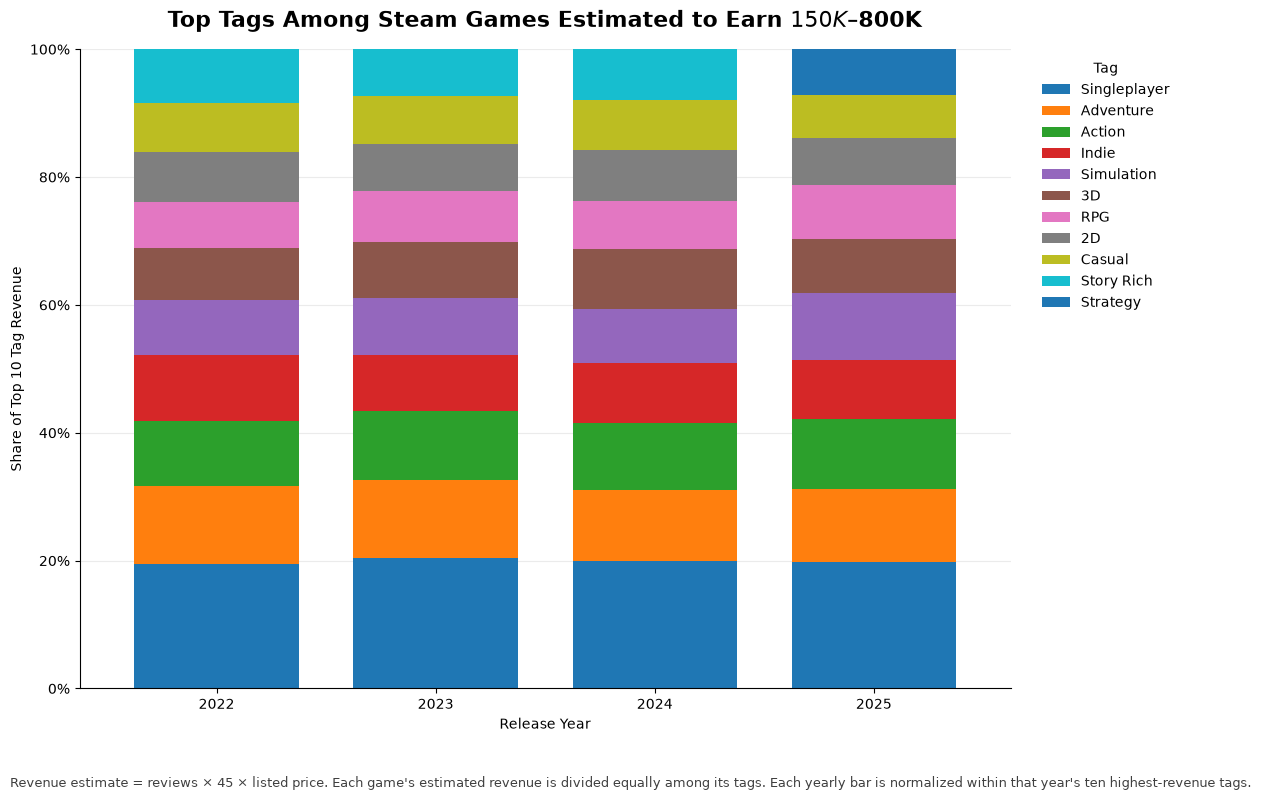

In [28]:
tag_share_pivot = (
    top_tags_by_year
    .pivot(
        index="release_year",
        columns="tag",
        values="share_of_top_10"
    )
    .fillna(0)
    .sort_index()
)

tag_order = (
    tag_share_pivot
    .sum(axis=0)
    .sort_values(ascending=False)
    .index
)

tag_share_pivot = tag_share_pivot[
    tag_order
]

fig, ax = plt.subplots(
    figsize=(15, 8)
)

tag_share_pivot.plot(
    kind="bar",
    stacked=True,
    width=0.75,
    ax=ax
)

ax.set_title(
    (
        "Top Tags Among Steam Games Estimated "
        "to Earn $150K–$800K"
    ),
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Share of Top 10 Tag Revenue")

ax.set_ylim(0, 100)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"{value:.0f}%"
    )
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.legend(
    title="Tag",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Revenue estimate = reviews × "
        f"{REVIEW_MULTIPLIER} × listed price. "
        "Each game's estimated revenue is divided equally "
        "among its tags. Each yearly bar is normalized "
        "within that year's ten highest-revenue tags."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.06, 0.80, 1]
)

plt.show()

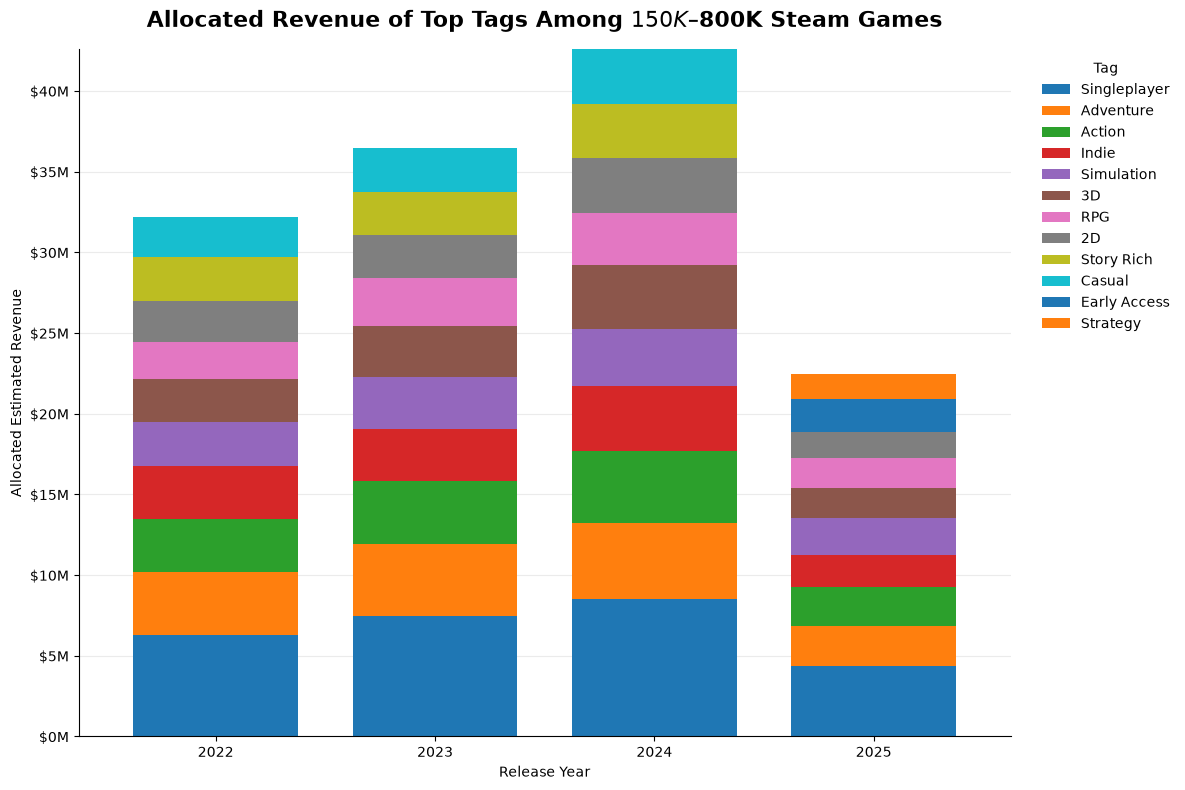

In [18]:
absolute_tag_pivot = (
    top_tags_by_year
    .pivot(
        index="release_year",
        columns="tag",
        values="allocated_revenue"
    )
    .fillna(0)
    .sort_index()
)

absolute_tag_pivot = absolute_tag_pivot[
    [
        column
        for column in tag_order
        if column in absolute_tag_pivot.columns
    ]
]

fig, ax = plt.subplots(
    figsize=(15, 8)
)

absolute_tag_pivot.plot(
    kind="bar",
    stacked=True,
    width=0.75,
    ax=ax
)

ax.set_title(
    (
        "Allocated Revenue of Top Tags Among "
        "$150K–$800K Steam Games"
    ),
    fontsize=16,
    fontweight="bold",
    pad=16
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Allocated Estimated Revenue")

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position:
        f"${value / 1_000_000:.0f}M"
    )
)

ax.tick_params(
    axis="x",
    rotation=0
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.legend(
    title="Tag",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout(
    rect=[0, 0, 0.80, 1]
)

plt.show()

In [19]:
top_tag_frequency = (
    top_tags_by_year[
        [
            "release_year",
            "rank",
            "tag",
            "games",
            "allocated_revenue",
            "median_game_revenue"
        ]
    ]
    .sort_values(
        [
            "release_year",
            "rank"
        ]
    )
)

display(
    top_tag_frequency.style.format({
        "games": "{:,.0f}",
        "allocated_revenue": "${:,.0f}",
        "median_game_revenue": "${:,.0f}"
    }).hide(axis="index")
)

release_year,rank,tag,games,allocated_revenue,median_game_revenue
2022,1,Singleplayer,311,"$6,286,195","$304,897"
2022,2,Adventure,191,"$3,913,340","$304,897"
2022,3,Indie,157,"$3,289,517","$308,494"
2022,4,Action,169,"$3,272,983","$296,985"
2022,5,Simulation,137,"$2,747,603","$314,257"
2022,6,Story Rich,129,"$2,739,049","$318,329"
2022,7,3D,141,"$2,637,120","$279,038"
2022,8,2D,131,"$2,509,138","$287,610"
2022,9,Casual,132,"$2,480,453","$301,769"
2022,10,RPG,117,"$2,325,512","$279,899"


In [29]:
from itertools import combinations

import numpy as np
import pandas as pd


def create_tag_jaccard_matrix(
    games_data,
    selected_tags,
    tag_column="tag_list"
):
    """
    Calculate pairwise Jaccard similarity between selected tags.

    Jaccard(A, B) =
        games containing both A and B
        divided by
        games containing A or B
    """

    selected_tags = list(selected_tags)

    matrix = pd.DataFrame(
        0.0,
        index=selected_tags,
        columns=selected_tags
    )

    # Convert each game's tags to a set
    game_tag_sets = games_data[tag_column].apply(set)

    for tag in selected_tags:
        matrix.loc[tag, tag] = 1.0

    for tag_a, tag_b in combinations(selected_tags, 2):

        contains_a = game_tag_sets.apply(
            lambda tags: tag_a in tags
        )

        contains_b = game_tag_sets.apply(
            lambda tags: tag_b in tags
        )

        intersection = (
            contains_a & contains_b
        ).sum()

        union = (
            contains_a | contains_b
        ).sum()

        similarity = (
            intersection / union
            if union > 0
            else 0
        )

        matrix.loc[tag_a, tag_b] = similarity
        matrix.loc[tag_b, tag_a] = similarity

    return matrix

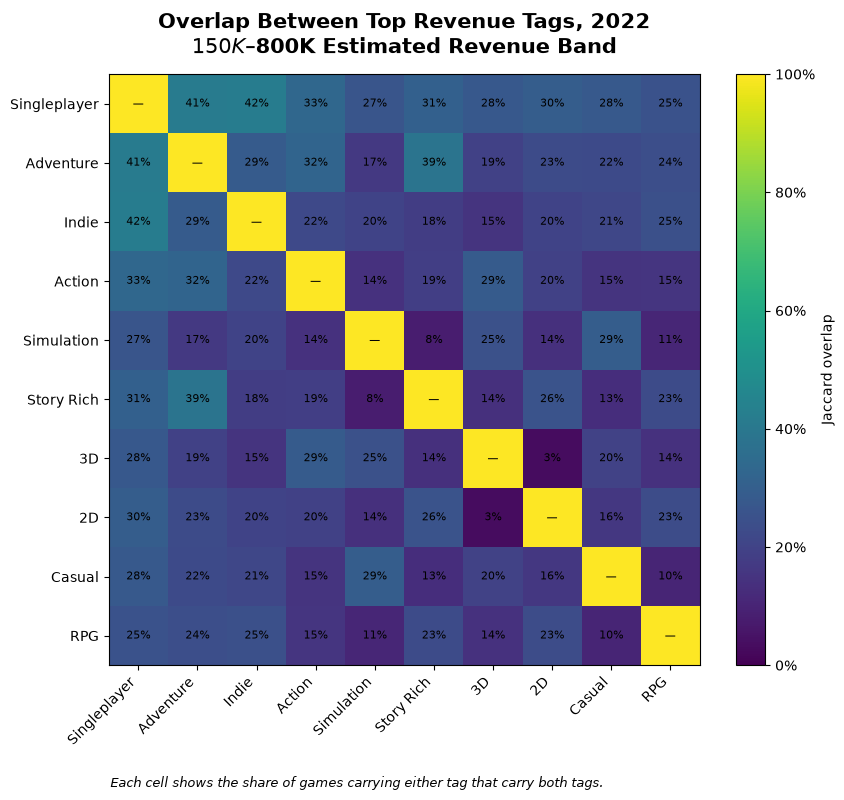

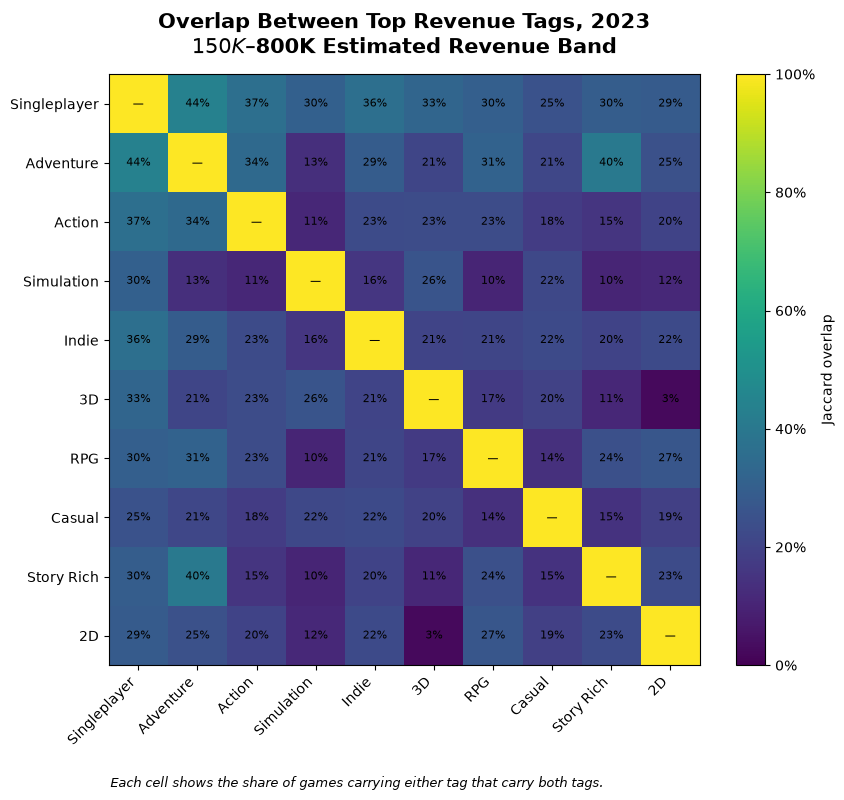

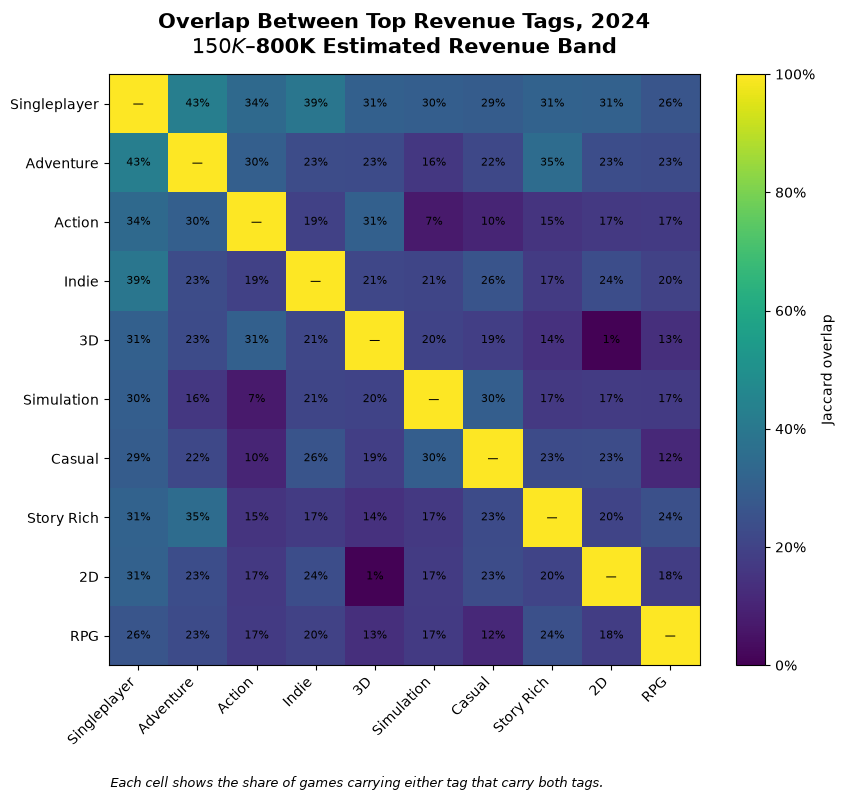

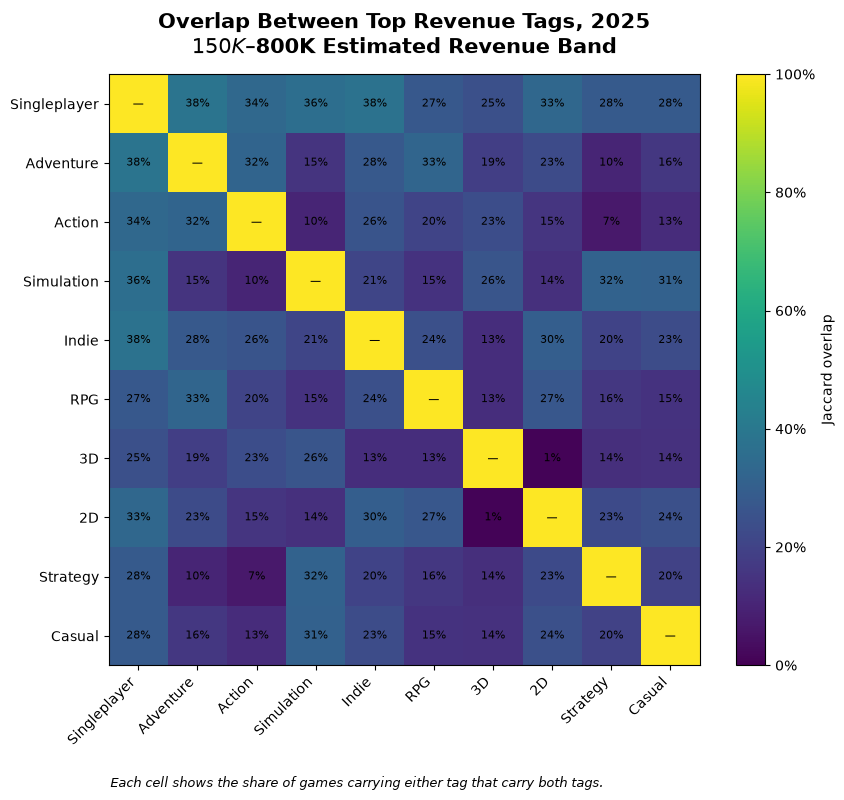

In [30]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


for year in range(2022, 2026):

    year_games = revenue_band_games.loc[
        revenue_band_games["release_year"] == year
    ].copy()

    year_top_tags = (
        top_tags_by_year.loc[
            top_tags_by_year["release_year"] == year
        ]
        .sort_values("rank")["tag"]
        .tolist()
    )

    if len(year_top_tags) < 2:
        print(f"Not enough tags for {year}")
        continue

    overlap_matrix = create_tag_jaccard_matrix(
        games_data=year_games,
        selected_tags=year_top_tags
    )

    fig, ax = plt.subplots(figsize=(10, 8))

    image = ax.imshow(
        overlap_matrix.values,
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    ax.set_xticks(
        range(len(year_top_tags))
    )

    ax.set_yticks(
        range(len(year_top_tags))
    )

    ax.set_xticklabels(
        year_top_tags,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(
        year_top_tags
    )

    # Add percentages inside the cells
    for row in range(len(year_top_tags)):
        for column in range(len(year_top_tags)):

            value = overlap_matrix.iloc[
                row,
                column
            ]

            # Do not label the diagonal
            if row == column:
                label = "—"
            else:
                label = f"{value:.0%}"

            ax.text(
                column,
                row,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    colorbar.set_label(
        "Jaccard overlap"
    )

    colorbar.ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    ax.set_title(
        (
            f"Overlap Between Top Revenue Tags, {year}\n"
            "$150K–$800K Estimated Revenue Band"
        ),
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    fig.text(
        0.5,
        0.01,
        (
            "Each cell shows the share of games carrying either tag "
            "that carry both tags."
        ),
        ha="center",
        fontsize=9,
        style="italic"
    )

    plt.tight_layout(
        rect=[0, 0.04, 1, 1]
    )

    plt.show()

In [31]:
yearly_overlap_summary = []

for year in range(2022, 2026):

    year_games = revenue_band_games.loc[
        revenue_band_games["release_year"] == year
    ]

    year_top_tags = (
        top_tags_by_year.loc[
            top_tags_by_year["release_year"] == year
        ]
        .sort_values("rank")["tag"]
        .tolist()
    )

    if len(year_top_tags) < 2:
        continue

    matrix = create_tag_jaccard_matrix(
        year_games,
        year_top_tags
    )

    # Extract only the upper triangle,
    # excluding the diagonal
    upper_triangle = matrix.values[
        np.triu_indices_from(
            matrix.values,
            k=1
        )
    ]

    yearly_overlap_summary.append({
        "release_year": year,
        "top_tags": len(year_top_tags),
        "mean_pairwise_overlap": upper_triangle.mean(),
        "median_pairwise_overlap": np.median(
            upper_triangle
        ),
        "maximum_pairwise_overlap": upper_triangle.max(),
        "pairs_with_no_overlap": (
            upper_triangle == 0
        ).sum(),
        "total_tag_pairs": len(upper_triangle)
    })

yearly_overlap_summary = pd.DataFrame(
    yearly_overlap_summary
)

yearly_overlap_summary[
    "share_of_pairs_with_no_overlap"
] = (
    yearly_overlap_summary["pairs_with_no_overlap"]
    / yearly_overlap_summary["total_tag_pairs"]
)

display(
    yearly_overlap_summary.style.format({
        "mean_pairwise_overlap": "{:.1%}",
        "median_pairwise_overlap": "{:.1%}",
        "maximum_pairwise_overlap": "{:.1%}",
        "share_of_pairs_with_no_overlap": "{:.1%}"
    }).hide(axis="index")
)

release_year,top_tags,mean_pairwise_overlap,median_pairwise_overlap,maximum_pairwise_overlap,pairs_with_no_overlap,total_tag_pairs,share_of_pairs_with_no_overlap
2022,10,22.0%,22.1%,41.8%,0,45,0.0%
2023,10,22.6%,22.3%,44.0%,0,45,0.0%
2024,10,22.3%,21.5%,42.9%,0,45,0.0%
2025,10,22.1%,22.7%,38.5%,0,45,0.0%


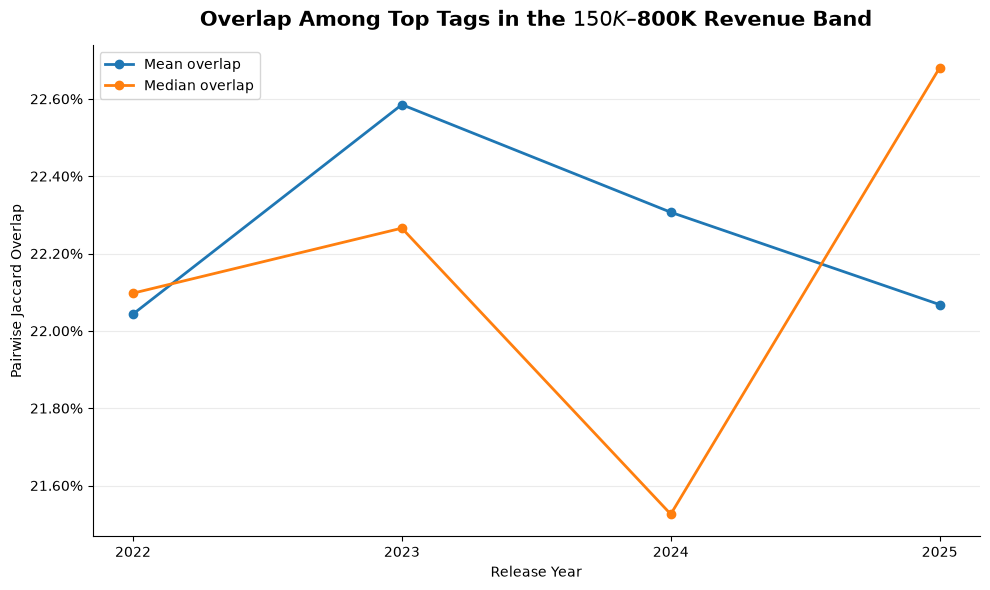

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(
    yearly_overlap_summary["release_year"],
    yearly_overlap_summary["mean_pairwise_overlap"] * 100,
    marker="o",
    linewidth=2,
    label="Mean overlap"
)

ax.plot(
    yearly_overlap_summary["release_year"],
    yearly_overlap_summary["median_pairwise_overlap"] * 100,
    marker="o",
    linewidth=2,
    label="Median overlap"
)

ax.set_title(
    "Overlap Among Top Tags in the $150K–$800K Revenue Band",
    fontsize=15,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Pairwise Jaccard Overlap")

ax.set_xticks(
    yearly_overlap_summary["release_year"]
)

ax.yaxis.set_major_formatter(
    PercentFormatter()
)

ax.legend()

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [33]:
ALL_STEAM_START_YEAR = 2022
ALL_STEAM_END_YEAR = 2025
TOP_N = 10

all_steam_games = df.loc[
    df["release_year"].between(
        ALL_STEAM_START_YEAR,
        ALL_STEAM_END_YEAR,
        inclusive="both"
    )
    & df["price"].gt(0)
    & df["estimated_revenue"].gt(0)
    & df["tag_count"].gt(0)
].copy()

print(f"Games included: {len(all_steam_games):,}")

print(
    all_steam_games
    .groupby("release_year")
    .size()
)

Games included: 34,712
release_year
2022     8063
2023     9128
2024    11783
2025     5738
dtype: int64


In [34]:
all_steam_games["revenue_per_tag"] = (
    all_steam_games["estimated_revenue"]
    / all_steam_games["tag_count"]
)

all_steam_tag_rows = (
    all_steam_games[
        [
            "appid",
            "name",
            "release_year",
            "estimated_revenue",
            "tag_list",
            "tag_count",
            "revenue_per_tag"
        ]
    ]
    .explode("tag_list")
    .rename(columns={"tag_list": "tag"})
)

all_steam_tag_rows.head()

,appid,name,release_year,estimated_revenue,tag,tag_count,revenue_per_tag
6,1934300,Armored Brigade II,2025,210541.5,Simulation,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,Strategy,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,RTS,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,Wargame,18,11696.75
6,1934300,Armored Brigade II,2025,210541.5,Grand Strategy,18,11696.75


In [35]:
all_steam_original_revenue = (
    all_steam_games["estimated_revenue"].sum()
)

all_steam_allocated_revenue = (
    all_steam_tag_rows["revenue_per_tag"].sum()
)

print(
    f"Original estimated revenue: "
    f"${all_steam_original_revenue:,.2f}"
)

print(
    f"Allocated tag revenue:      "
    f"${all_steam_allocated_revenue:,.2f}"
)

print(
    f"Difference:                 "
    f"${all_steam_allocated_revenue - all_steam_original_revenue:,.6f}"
)

assert np.isclose(
    all_steam_original_revenue,
    all_steam_allocated_revenue
)

Original estimated revenue: $24,468,527,213.10
Allocated tag revenue:      $24,468,527,213.10
Difference:                 $0.000000


In [36]:
all_steam_tag_performance = (
    all_steam_tag_rows
    .groupby(
        ["release_year", "tag"],
        as_index=False
    )
    .agg(
        allocated_revenue=(
            "revenue_per_tag",
            "sum"
        ),
        games=(
            "appid",
            "nunique"
        ),
        median_game_revenue=(
            "estimated_revenue",
            "median"
        ),
        mean_game_revenue=(
            "estimated_revenue",
            "mean"
        )
    )
    .sort_values(
        ["release_year", "allocated_revenue"],
        ascending=[True, False]
    )
)

all_steam_top_tags = (
    all_steam_tag_performance
    .groupby(
        "release_year",
        group_keys=False
    )
    .head(TOP_N)
    .copy()
)

all_steam_top_tags["rank"] = (
    all_steam_top_tags
    .groupby("release_year")
    .cumcount()
    .add(1)
)

display(
    all_steam_top_tags[
        [
            "release_year",
            "rank",
            "tag",
            "games",
            "allocated_revenue",
            "median_game_revenue"
        ]
    ]
    .style
    .format({
        "games": "{:,.0f}",
        "allocated_revenue": "${:,.0f}",
        "median_game_revenue": "${:,.0f}"
    })
    .hide(axis="index")
)

release_year,rank,tag,games,allocated_revenue,median_game_revenue
2022,1,Singleplayer,"6,246","$242,874,426","$1,970"
2022,2,Action,"3,428","$221,800,366","$1,798"
2022,3,Open World,643,"$181,844,778","$5,395"
2022,4,Multiplayer,871,"$181,344,477","$6,051"
2022,5,Third Person,912,"$164,281,192","$2,149"
2022,6,RPG,"1,572","$161,655,396","$4,043"
2022,7,Atmospheric,"1,896","$151,420,828","$2,939"
2022,8,3D,"2,567","$140,156,143","$2,003"
2022,9,Co-op,421,"$139,649,436","$9,441"
2022,10,Character Customization,549,"$129,915,647","$4,119"


In [37]:
from itertools import combinations


def create_tag_jaccard_matrix(
    games_data,
    selected_tags,
    tag_column="tag_list"
):
    """
    Pairwise Jaccard overlap:

        games containing both tags
        ---------------------------
        games containing either tag
    """

    selected_tags = list(selected_tags)

    matrix = pd.DataFrame(
        0.0,
        index=selected_tags,
        columns=selected_tags
    )

    game_tag_sets = games_data[tag_column].apply(set)

    for tag in selected_tags:
        matrix.loc[tag, tag] = 1.0

    for tag_a, tag_b in combinations(selected_tags, 2):

        contains_a = game_tag_sets.apply(
            lambda tags: tag_a in tags
        )

        contains_b = game_tag_sets.apply(
            lambda tags: tag_b in tags
        )

        intersection = (
            contains_a & contains_b
        ).sum()

        union = (
            contains_a | contains_b
        ).sum()

        overlap = (
            intersection / union
            if union > 0
            else 0
        )

        matrix.loc[tag_a, tag_b] = overlap
        matrix.loc[tag_b, tag_a] = overlap

    return matrix

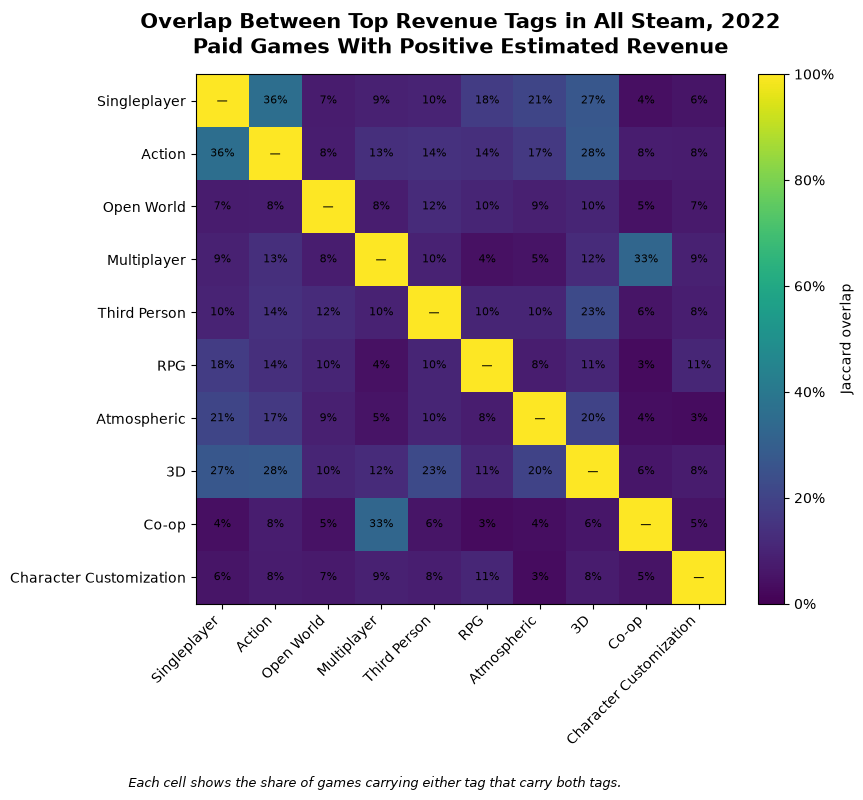

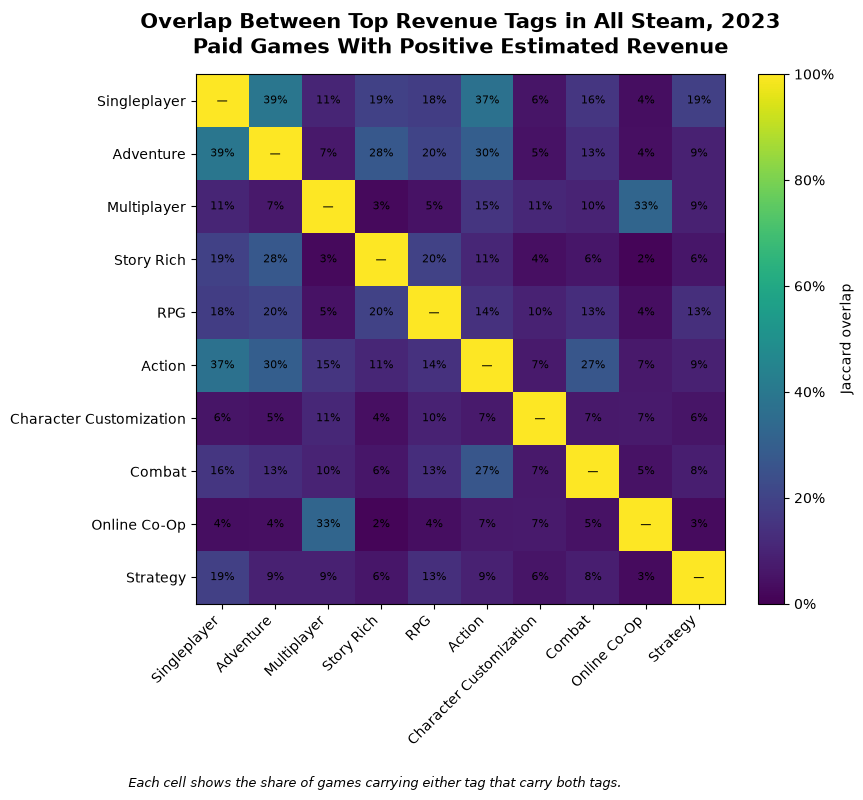

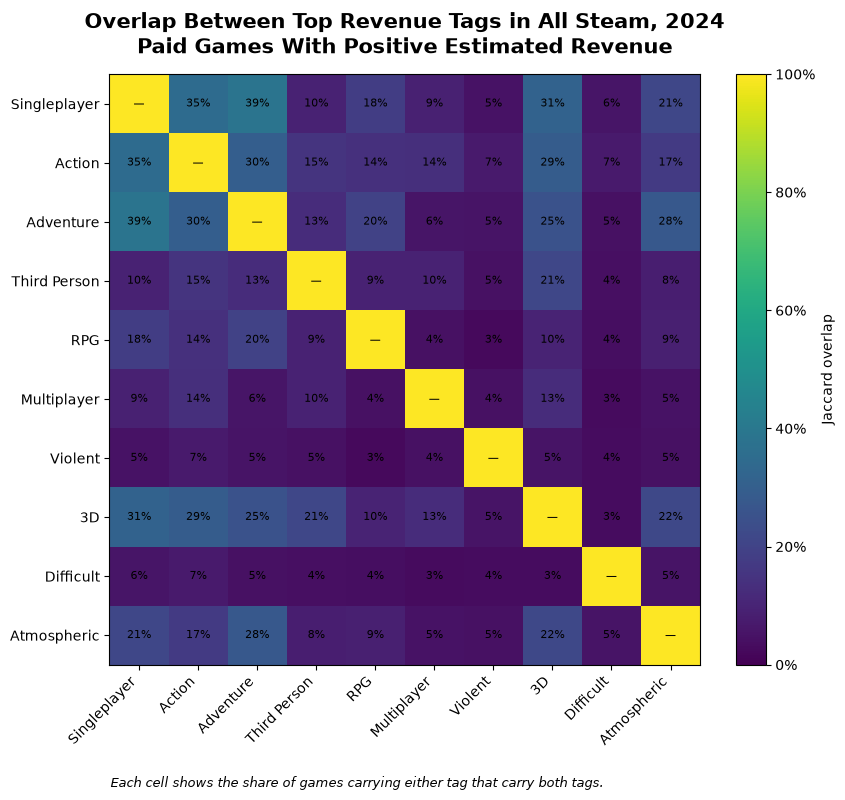

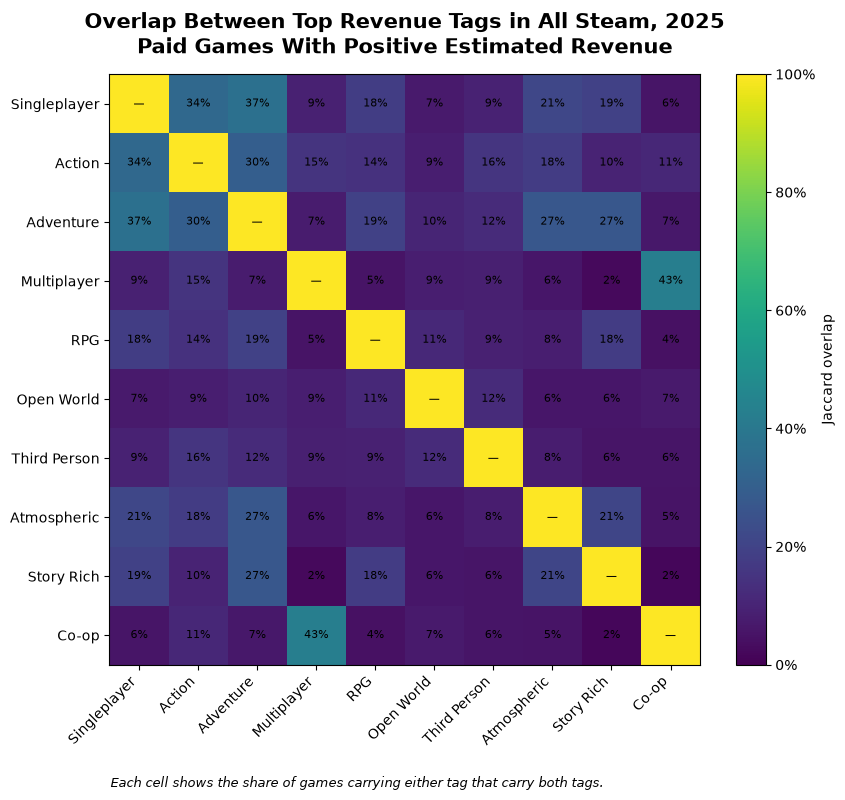

In [38]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


all_steam_overlap_matrices = {}

for year in range(
    ALL_STEAM_START_YEAR,
    ALL_STEAM_END_YEAR + 1
):

    year_games = all_steam_games.loc[
        all_steam_games["release_year"] == year
    ].copy()

    year_top_tags = (
        all_steam_top_tags.loc[
            all_steam_top_tags["release_year"] == year
        ]
        .sort_values("rank")["tag"]
        .tolist()
    )

    if len(year_top_tags) < 2:
        print(f"Not enough top tags for {year}")
        continue

    overlap_matrix = create_tag_jaccard_matrix(
        games_data=year_games,
        selected_tags=year_top_tags
    )

    all_steam_overlap_matrices[year] = overlap_matrix

    fig, ax = plt.subplots(figsize=(10, 8))

    image = ax.imshow(
        overlap_matrix.values,
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    ax.set_xticks(range(len(year_top_tags)))
    ax.set_yticks(range(len(year_top_tags)))

    ax.set_xticklabels(
        year_top_tags,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(year_top_tags)

    for row in range(len(year_top_tags)):
        for column in range(len(year_top_tags)):

            value = overlap_matrix.iloc[row, column]

            label = (
                "—"
                if row == column
                else f"{value:.0%}"
            )

            ax.text(
                column,
                row,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    colorbar.set_label("Jaccard overlap")

    colorbar.ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    ax.set_title(
        (
            f"Overlap Between Top Revenue Tags in All Steam, {year}\n"
            "Paid Games With Positive Estimated Revenue"
        ),
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    fig.text(
        0.5,
        0.01,
        (
            "Each cell shows the share of games carrying either "
            "tag that carry both tags."
        ),
        ha="center",
        fontsize=9,
        style="italic"
    )

    plt.tight_layout(
        rect=[0, 0.04, 1, 1]
    )

    plt.show()

In [39]:
def summarize_top_tag_overlap(
    games_data,
    top_tags_data,
    segment_name,
    start_year=2022,
    end_year=2025
):
    rows = []

    for year in range(start_year, end_year + 1):

        year_games = games_data.loc[
            games_data["release_year"] == year
        ]

        year_tags = (
            top_tags_data.loc[
                top_tags_data["release_year"] == year
            ]
            .sort_values("rank")["tag"]
            .tolist()
        )

        if len(year_tags) < 2:
            continue

        matrix = create_tag_jaccard_matrix(
            year_games,
            year_tags
        )

        overlaps = matrix.values[
            np.triu_indices_from(
                matrix.values,
                k=1
            )
        ]

        rows.append({
            "segment": segment_name,
            "release_year": year,
            "mean_overlap": overlaps.mean(),
            "median_overlap": np.median(overlaps),
            "maximum_overlap": overlaps.max(),
            "pairs_above_25_percent": (
                overlaps >= 0.25
            ).sum(),
            "pairs_above_50_percent": (
                overlaps >= 0.50
            ).sum(),
            "pairs_with_zero_overlap": (
                overlaps == 0
            ).sum(),
            "total_pairs": len(overlaps)
        })

    return pd.DataFrame(rows)

In [40]:
all_steam_overlap_summary = summarize_top_tag_overlap(
    games_data=all_steam_games,
    top_tags_data=all_steam_top_tags,
    segment_name="All Steam"
)

revenue_band_overlap_summary = summarize_top_tag_overlap(
    games_data=revenue_band_games,
    top_tags_data=top_tags_by_year,
    segment_name="$150K–$800K band"
)

overlap_comparison = pd.concat(
    [
        all_steam_overlap_summary,
        revenue_band_overlap_summary
    ],
    ignore_index=True
)

overlap_comparison["zero_overlap_share"] = (
    overlap_comparison["pairs_with_zero_overlap"]
    / overlap_comparison["total_pairs"]
)

display(
    overlap_comparison.style.format({
        "mean_overlap": "{:.1%}",
        "median_overlap": "{:.1%}",
        "maximum_overlap": "{:.1%}",
        "zero_overlap_share": "{:.1%}"
    }).hide(axis="index")
)

segment,release_year,mean_overlap,median_overlap,maximum_overlap,pairs_above_25_percent,pairs_above_50_percent,pairs_with_zero_overlap,total_pairs,zero_overlap_share
All Steam,2022,11.5%,9.2%,36.3%,4,0,0,45,0.0%
All Steam,2023,12.4%,9.4%,39.4%,6,0,0,45,0.0%
All Steam,2024,12.5%,9.2%,38.6%,7,0,0,45,0.0%
All Steam,2025,13.3%,9.4%,43.0%,6,0,0,45,0.0%
$150K–$800K band,2022,22.0%,22.1%,41.8%,15,0,0,45,0.0%
$150K–$800K band,2023,22.6%,22.3%,44.0%,15,0,0,45,0.0%
$150K–$800K band,2024,22.3%,21.5%,42.9%,14,0,0,45,0.0%
$150K–$800K band,2025,22.1%,22.7%,38.5%,17,0,0,45,0.0%


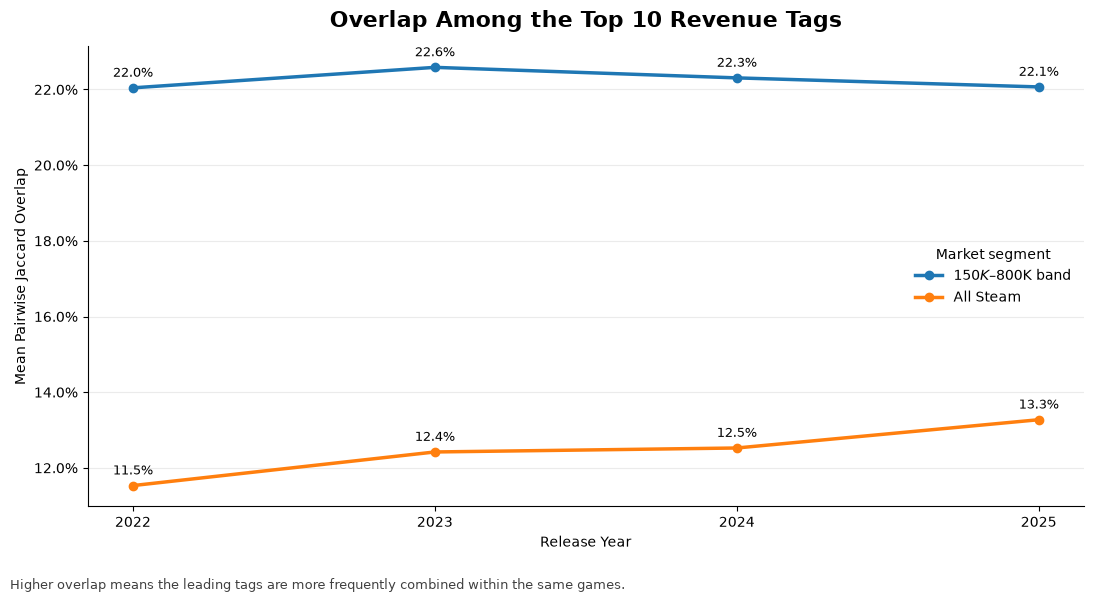

In [41]:
fig, ax = plt.subplots(figsize=(11, 6))

for segment, group in overlap_comparison.groupby("segment"):

    group = group.sort_values("release_year")

    ax.plot(
        group["release_year"],
        group["mean_overlap"] * 100,
        marker="o",
        linewidth=2.5,
        label=segment
    )

    for _, row in group.iterrows():
        ax.annotate(
            f'{row["mean_overlap"]:.1%}',
            xy=(
                row["release_year"],
                row["mean_overlap"] * 100
            ),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.set_title(
    "Overlap Among the Top 10 Revenue Tags",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Mean Pairwise Jaccard Overlap")

ax.set_xticks(range(2022, 2026))

ax.yaxis.set_major_formatter(
    PercentFormatter()
)

ax.legend(
    title="Market segment",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Higher overlap means the leading tags are more frequently "
        "combined within the same games."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

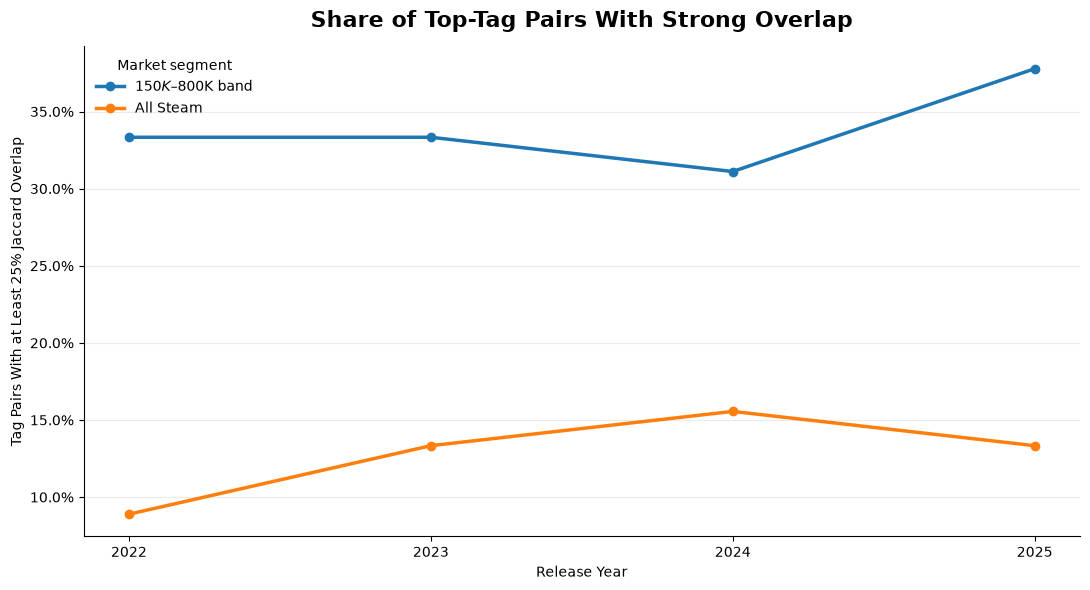

In [42]:
overlap_comparison["share_above_25_percent"] = (
    100
    * overlap_comparison["pairs_above_25_percent"]
    / overlap_comparison["total_pairs"]
)

fig, ax = plt.subplots(figsize=(11, 6))

for segment, group in overlap_comparison.groupby("segment"):

    group = group.sort_values("release_year")

    ax.plot(
        group["release_year"],
        group["share_above_25_percent"],
        marker="o",
        linewidth=2.5,
        label=segment
    )

ax.set_title(
    "Share of Top-Tag Pairs With Strong Overlap",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Tag Pairs With at Least 25% Jaccard Overlap")

ax.set_xticks(range(2022, 2026))

ax.yaxis.set_major_formatter(
    PercentFormatter()
)

ax.legend(
    title="Market segment",
    frameon=False
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd


def create_revenue_weighted_jaccard_matrix(
    games_data,
    selected_tags,
    tag_column="tag_list",
    revenue_column="estimated_revenue"
):
    """
    Calculate revenue-weighted Jaccard overlap between tags.

    For each game and tag:

        allocated contribution =
            estimated revenue / number of valid tags

    Weighted Jaccard(A, B) =
        sum(min(contribution_A, contribution_B))
        ------------------------------------------------
        sum(max(contribution_A, contribution_B))

    This measures how much of the revenue supporting either tag
    comes from games carrying both tags.
    """

    selected_tags = list(selected_tags)

    working = games_data[
        [tag_column, revenue_column]
    ].copy()

    working = working.loc[
        working[revenue_column].gt(0)
        & working[tag_column].apply(
            lambda tags: isinstance(tags, list) and len(tags) > 0
        )
    ].copy()

    working["tag_set"] = working[tag_column].apply(set)

    working["allocated_revenue"] = (
        working[revenue_column]
        / working[tag_column].apply(len)
    )

    # One revenue-contribution vector per tag
    contribution_vectors = {}

    for tag in selected_tags:
        contribution_vectors[tag] = np.where(
            working["tag_set"].apply(
                lambda tags: tag in tags
            ),
            working["allocated_revenue"],
            0.0
        )

    matrix = pd.DataFrame(
        0.0,
        index=selected_tags,
        columns=selected_tags
    )

    for tag_a in selected_tags:
        for tag_b in selected_tags:

            contribution_a = contribution_vectors[tag_a]
            contribution_b = contribution_vectors[tag_b]

            numerator = np.minimum(
                contribution_a,
                contribution_b
            ).sum()

            denominator = np.maximum(
                contribution_a,
                contribution_b
            ).sum()

            matrix.loc[tag_a, tag_b] = (
                numerator / denominator
                if denominator > 0
                else 0
            )

    return matrix

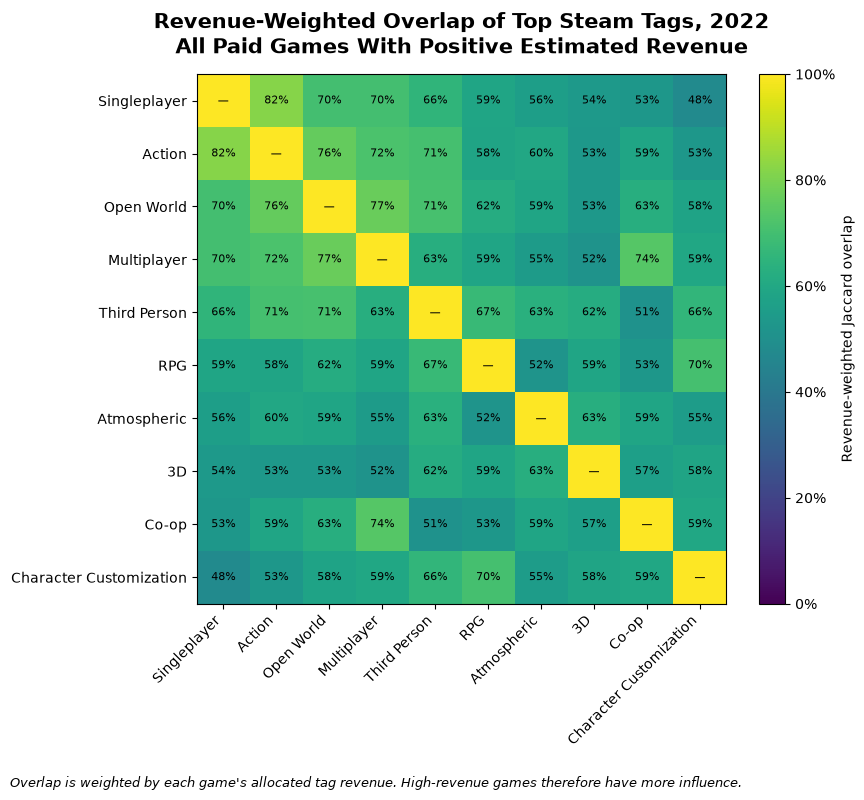

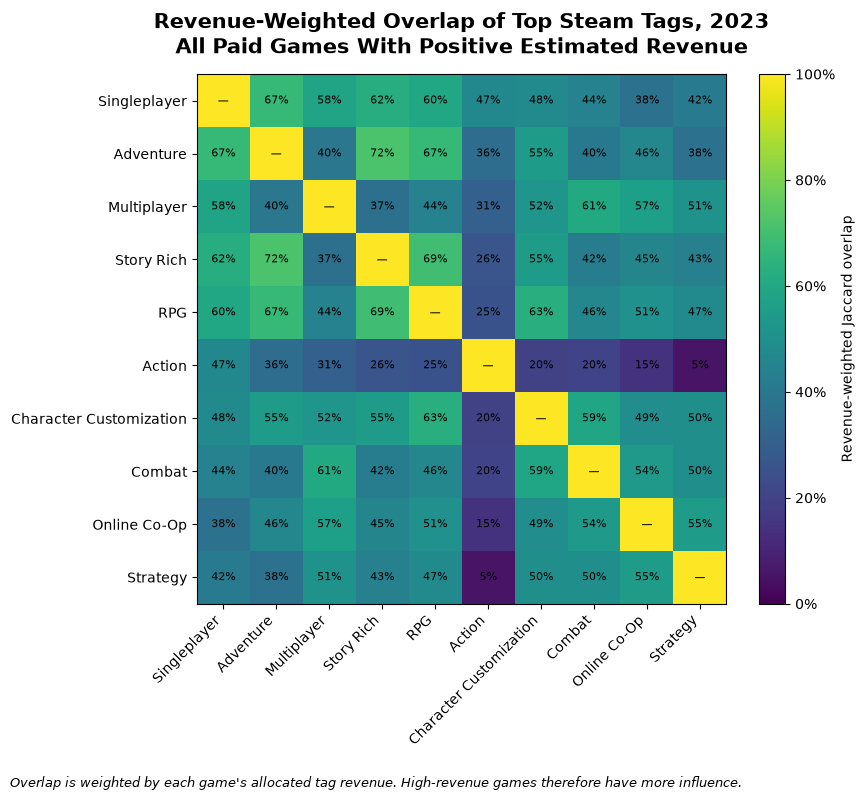

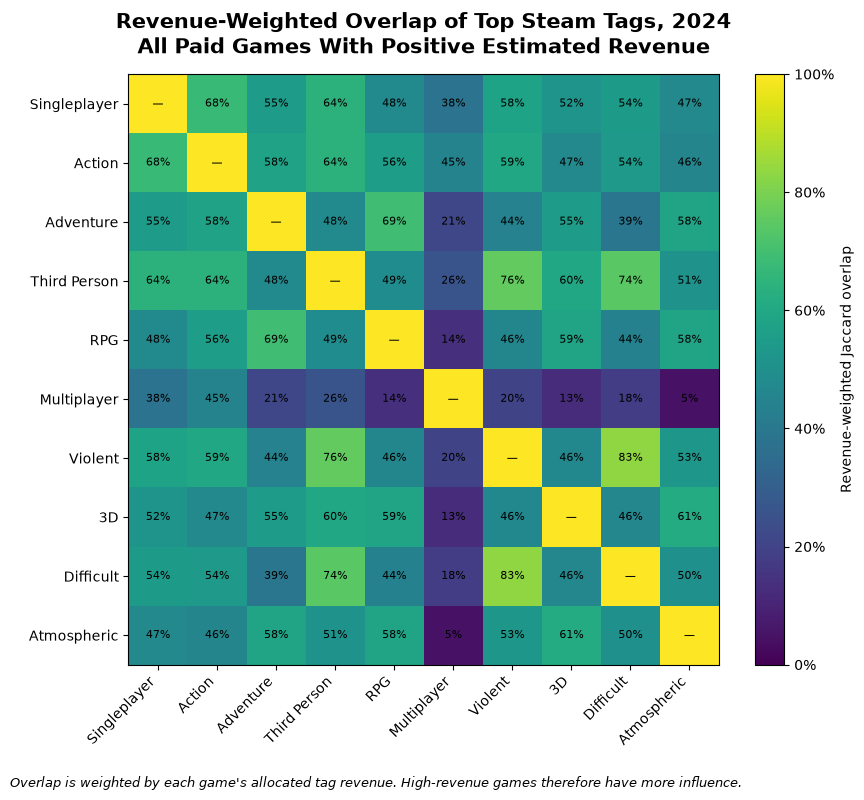

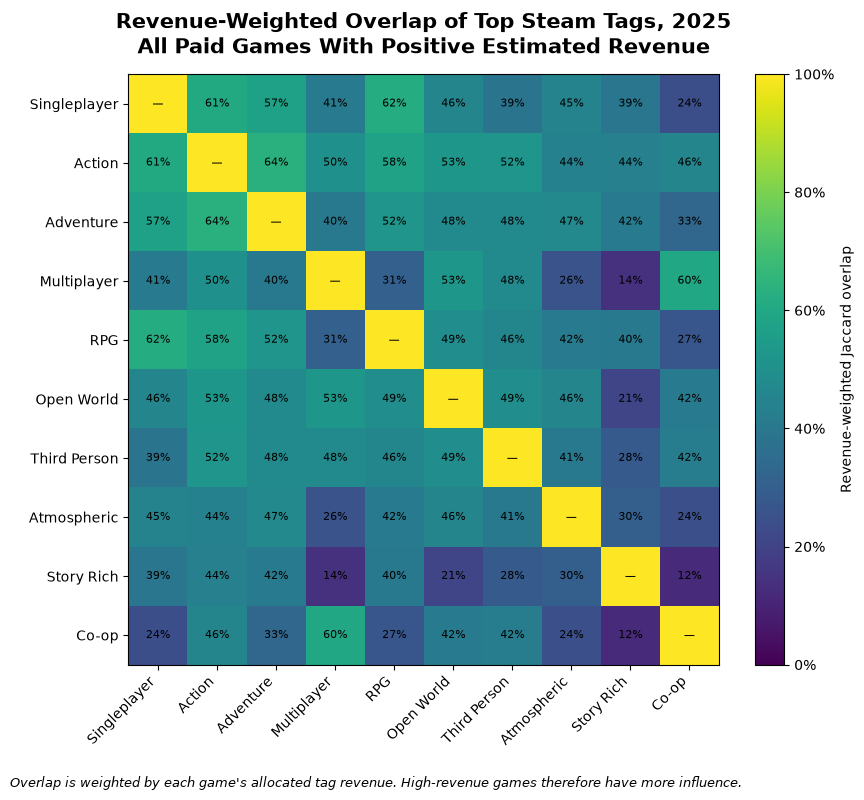

In [44]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter


all_steam_weighted_matrices = {}

for year in range(2022, 2026):

    year_games = all_steam_games.loc[
        all_steam_games["release_year"] == year
    ].copy()

    year_top_tags = (
        all_steam_top_tags.loc[
            all_steam_top_tags["release_year"] == year
        ]
        .sort_values("rank")["tag"]
        .tolist()
    )

    if len(year_top_tags) < 2:
        continue

    weighted_matrix = (
        create_revenue_weighted_jaccard_matrix(
            games_data=year_games,
            selected_tags=year_top_tags
        )
    )

    all_steam_weighted_matrices[year] = weighted_matrix

    fig, ax = plt.subplots(figsize=(10, 8))

    image = ax.imshow(
        weighted_matrix.values,
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    ax.set_xticks(range(len(year_top_tags)))
    ax.set_yticks(range(len(year_top_tags)))

    ax.set_xticklabels(
        year_top_tags,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(year_top_tags)

    for row in range(len(year_top_tags)):
        for column in range(len(year_top_tags)):

            value = weighted_matrix.iloc[
                row,
                column
            ]

            label = (
                "—"
                if row == column
                else f"{value:.0%}"
            )

            ax.text(
                column,
                row,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    colorbar.set_label(
        "Revenue-weighted Jaccard overlap"
    )

    colorbar.ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    ax.set_title(
        (
            f"Revenue-Weighted Overlap of Top Steam Tags, {year}\n"
            "All Paid Games With Positive Estimated Revenue"
        ),
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    fig.text(
        0.5,
        0.01,
        (
            "Overlap is weighted by each game's allocated tag revenue. "
            "High-revenue games therefore have more influence."
        ),
        ha="center",
        fontsize=9,
        style="italic"
    )

    plt.tight_layout(
        rect=[0, 0.04, 1, 1]
    )

    plt.show()

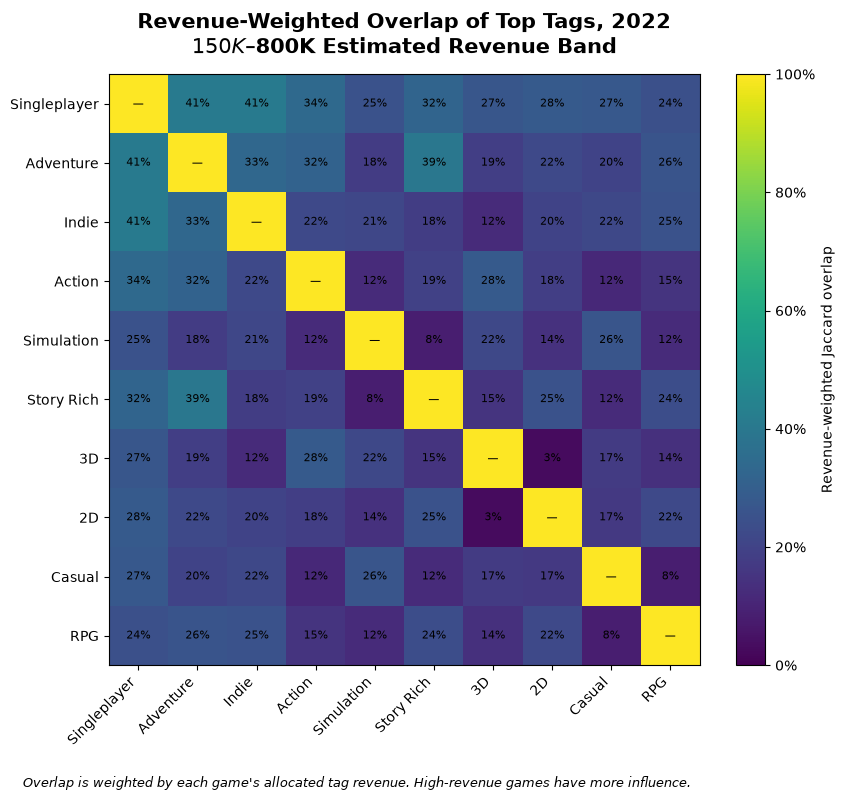

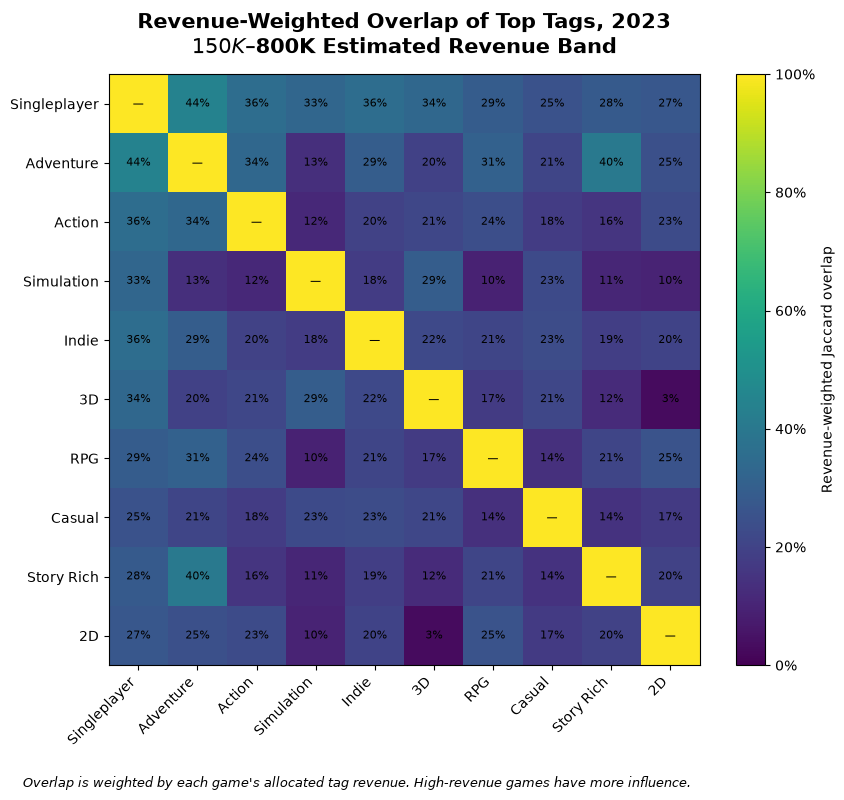

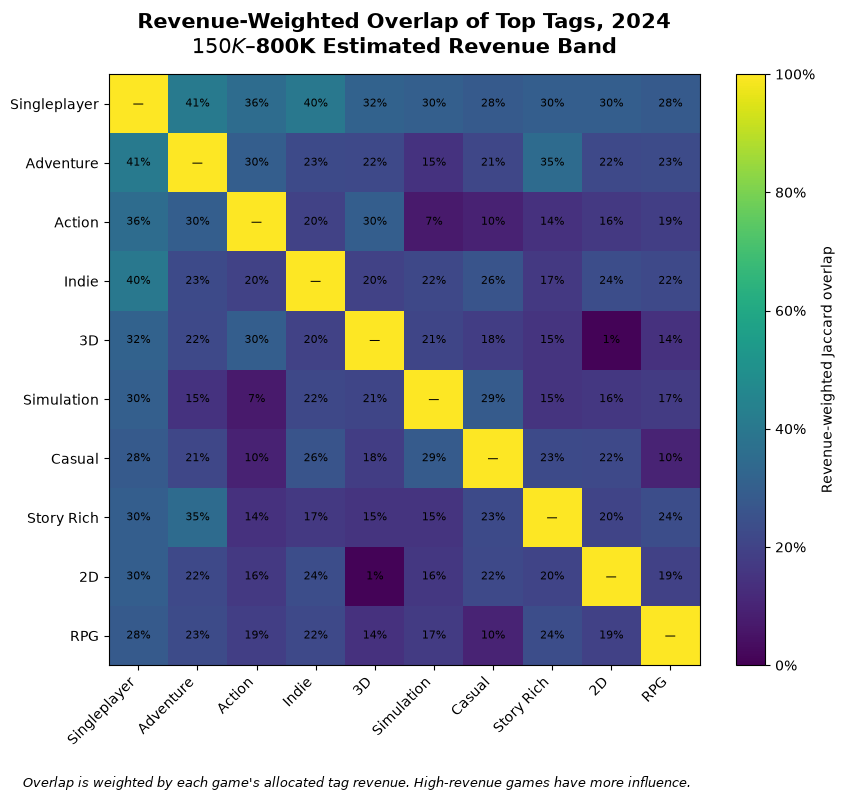

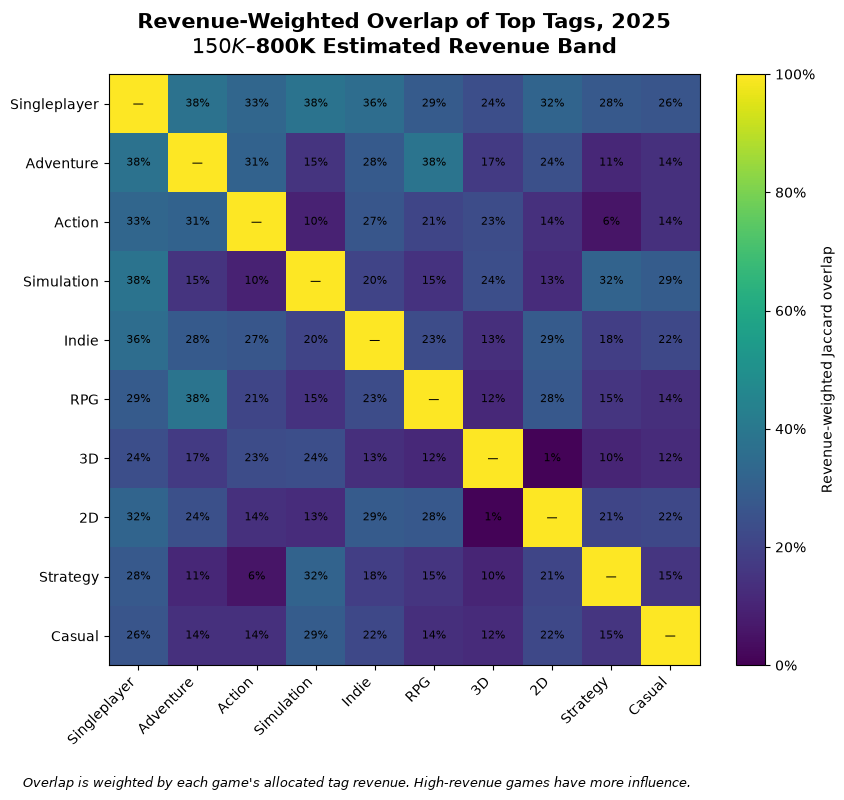

In [45]:
revenue_band_weighted_matrices = {}

for year in range(2022, 2026):

    year_games = revenue_band_games.loc[
        revenue_band_games["release_year"] == year
    ].copy()

    year_top_tags = (
        top_tags_by_year.loc[
            top_tags_by_year["release_year"] == year
        ]
        .sort_values("rank")["tag"]
        .tolist()
    )

    if len(year_top_tags) < 2:
        continue

    weighted_matrix = (
        create_revenue_weighted_jaccard_matrix(
            games_data=year_games,
            selected_tags=year_top_tags
        )
    )

    revenue_band_weighted_matrices[year] = weighted_matrix

    fig, ax = plt.subplots(figsize=(10, 8))

    image = ax.imshow(
        weighted_matrix.values,
        vmin=0,
        vmax=1,
        aspect="equal"
    )

    ax.set_xticks(range(len(year_top_tags)))
    ax.set_yticks(range(len(year_top_tags)))

    ax.set_xticklabels(
        year_top_tags,
        rotation=45,
        ha="right"
    )

    ax.set_yticklabels(year_top_tags)

    for row in range(len(year_top_tags)):
        for column in range(len(year_top_tags)):

            value = weighted_matrix.iloc[
                row,
                column
            ]

            label = (
                "—"
                if row == column
                else f"{value:.0%}"
            )

            ax.text(
                column,
                row,
                label,
                ha="center",
                va="center",
                fontsize=8
            )

    colorbar = fig.colorbar(
        image,
        ax=ax,
        fraction=0.046,
        pad=0.04
    )

    colorbar.set_label(
        "Revenue-weighted Jaccard overlap"
    )

    colorbar.ax.yaxis.set_major_formatter(
        PercentFormatter(xmax=1)
    )

    ax.set_title(
        (
            f"Revenue-Weighted Overlap of Top Tags, {year}\n"
            "$150K–$800K Estimated Revenue Band"
        ),
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    fig.text(
        0.5,
        0.01,
        (
            "Overlap is weighted by each game's allocated tag revenue. "
            "High-revenue games have more influence."
        ),
        ha="center",
        fontsize=9,
        style="italic"
    )

    plt.tight_layout(
        rect=[0, 0.04, 1, 1]
    )

    plt.show()

In [46]:
def summarize_weighted_overlap(
    games_data,
    top_tags_data,
    segment_name,
    start_year=2022,
    end_year=2025
):
    rows = []

    for year in range(start_year, end_year + 1):

        year_games = games_data.loc[
            games_data["release_year"] == year
        ]

        year_tags = (
            top_tags_data.loc[
                top_tags_data["release_year"] == year
            ]
            .sort_values("rank")["tag"]
            .tolist()
        )

        if len(year_tags) < 2:
            continue

        matrix = create_revenue_weighted_jaccard_matrix(
            games_data=year_games,
            selected_tags=year_tags
        )

        overlaps = matrix.values[
            np.triu_indices_from(
                matrix.values,
                k=1
            )
        ]

        rows.append({
            "segment": segment_name,
            "release_year": year,
            "games": year_games["appid"].nunique(),
            "mean_weighted_overlap": overlaps.mean(),
            "median_weighted_overlap": np.median(overlaps),
            "maximum_weighted_overlap": overlaps.max(),
            "pairs_above_25_percent": (
                overlaps >= 0.25
            ).sum(),
            "pairs_above_50_percent": (
                overlaps >= 0.50
            ).sum(),
            "total_pairs": len(overlaps)
        })

    return pd.DataFrame(rows)


all_steam_weighted_summary = summarize_weighted_overlap(
    games_data=all_steam_games,
    top_tags_data=all_steam_top_tags,
    segment_name="All Steam"
)

band_weighted_summary = summarize_weighted_overlap(
    games_data=revenue_band_games,
    top_tags_data=top_tags_by_year,
    segment_name="$150K–$800K band"
)

weighted_overlap_comparison = pd.concat(
    [
        all_steam_weighted_summary,
        band_weighted_summary
    ],
    ignore_index=True
)

display(
    weighted_overlap_comparison.style.format({
        "games": "{:,.0f}",
        "mean_weighted_overlap": "{:.1%}",
        "median_weighted_overlap": "{:.1%}",
        "maximum_weighted_overlap": "{:.1%}"
    }).hide(axis="index")
)

segment,release_year,games,mean_weighted_overlap,median_weighted_overlap,maximum_weighted_overlap,pairs_above_25_percent,pairs_above_50_percent,total_pairs
All Steam,2022,"8,063",61.3%,58.9%,81.9%,45,44,45
All Steam,2023,"9,128",46.3%,47.5%,71.6%,41,18,45
All Steam,2024,"11,783",48.9%,51.2%,83.4%,39,24,45
All Steam,2025,"5,738",42.3%,44.0%,63.6%,40,11,45
$150K–$800K band,2022,425,21.7%,21.5%,41.3%,16,0,45
$150K–$800K band,2023,482,22.4%,21.3%,44.2%,15,0,45
$150K–$800K band,2024,572,22.1%,21.9%,41.2%,14,0,45
$150K–$800K band,2025,326,21.4%,21.5%,38.5%,16,0,45


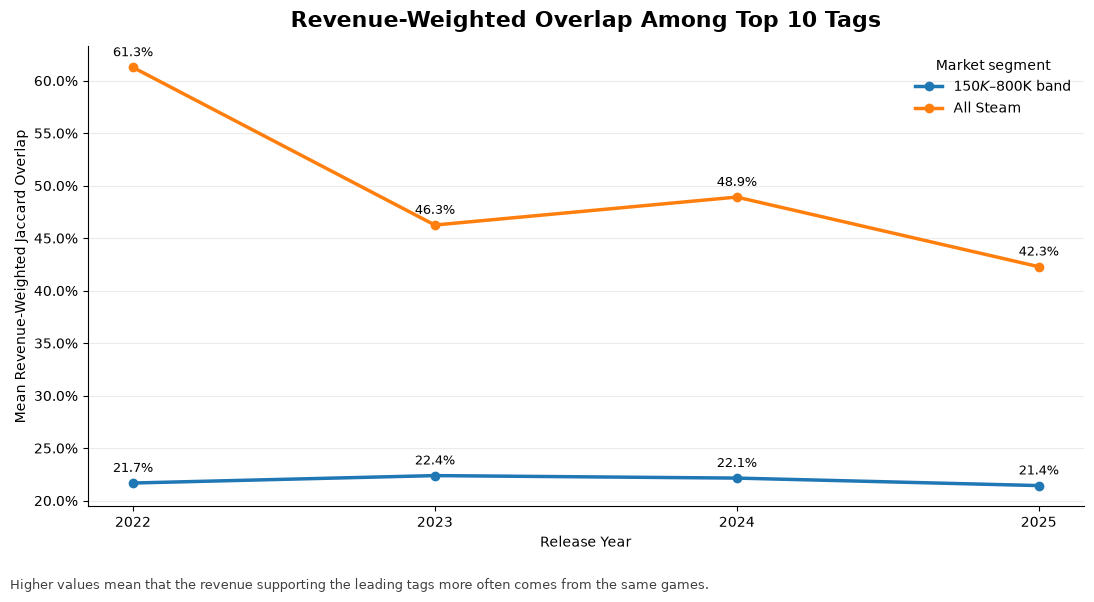

In [47]:
fig, ax = plt.subplots(figsize=(11, 6))

for segment, group in weighted_overlap_comparison.groupby(
    "segment"
):
    group = group.sort_values("release_year")

    ax.plot(
        group["release_year"],
        group["mean_weighted_overlap"] * 100,
        marker="o",
        linewidth=2.5,
        label=segment
    )

    for _, row in group.iterrows():
        ax.annotate(
            f'{row["mean_weighted_overlap"]:.1%}',
            xy=(
                row["release_year"],
                row["mean_weighted_overlap"] * 100
            ),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            fontsize=9
        )

ax.set_title(
    "Revenue-Weighted Overlap Among Top 10 Tags",
    fontsize=16,
    fontweight="bold",
    pad=14
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Mean Revenue-Weighted Jaccard Overlap")

ax.set_xticks(range(2022, 2026))

ax.yaxis.set_major_formatter(
    PercentFormatter()
)

ax.legend(
    title="Market segment",
    frameon=False
)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Higher values mean that the revenue supporting the leading tags "
        "more often comes from the same games."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

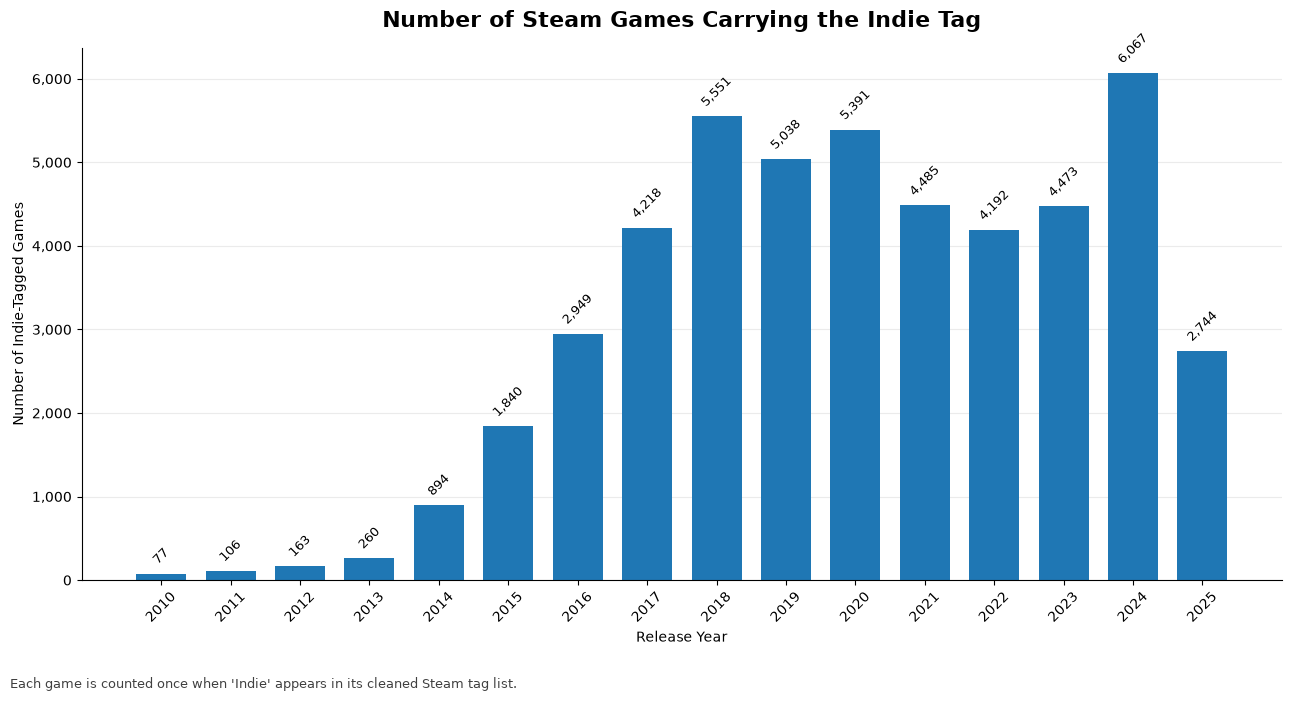

,release_year,indie_games
0,2010,77
1,2011,106
2,2012,163
3,2013,260
4,2014,894
5,2015,1840
6,2016,2949
7,2017,4218
8,2018,5551
9,2019,5038


In [49]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

START_YEAR = 2010
END_YEAR = 2025
TARGET_TAG = "Indie"

# Identify games carrying the Indie tag
indie_games = df.loc[
    df["release_year"].between(
        START_YEAR,
        END_YEAR,
        inclusive="both"
    )
    & df["tag_list"].apply(
        lambda tags: TARGET_TAG in tags
    )
].copy()

# Count Indie-tagged games by year
indie_games_by_year = (
    indie_games
    .groupby("release_year")
    .agg(
        indie_games=("appid", "nunique")
    )
    .reindex(
        range(START_YEAR, END_YEAR + 1),
        fill_value=0
    )
    .rename_axis("release_year")
    .reset_index()
)

# Plot
fig, ax = plt.subplots(figsize=(13, 7))

bars = ax.bar(
    indie_games_by_year["release_year"],
    indie_games_by_year["indie_games"],
    width=0.72
)

# Add values above the bars
for bar, count in zip(
    bars,
    indie_games_by_year["indie_games"]
):
    ax.annotate(
        f"{int(count):,}",
        xy=(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=9,
        rotation=45
    )

ax.set_title(
    "Number of Steam Games Carrying the Indie Tag",
    fontsize=16,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Indie-Tagged Games")

ax.set_xticks(
    indie_games_by_year["release_year"]
)

ax.tick_params(
    axis="x",
    rotation=45
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda value, position: f"{value:,.0f}"
    )
)

ax.grid(
    axis="y",
    alpha=0.25
)

ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Each game is counted once when 'Indie' appears in its "
        "cleaned Steam tag list."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(
    rect=[0, 0.05, 1, 1]
)

plt.show()

indie_games_by_year

In [50]:
indie_summary = (
    df.assign(
        has_indie=df["tag_list"].apply(lambda tags: "Indie" in tags)
    )
    .groupby("release_year")
    .agg(
        total_games=("appid", "count"),
        indie_games=("has_indie", "sum")
    )
)

indie_summary["share"] = (
    100 * indie_summary["indie_games"] / indie_summary["total_games"]
)

display(indie_summary)

,total_games,indie_games,share
release_year,,,
1997,2,1,50.000000
1998,1,0,0.000000
1999,2,0,0.000000
2000,2,0,0.000000
2001,4,1,25.000000
2002,1,0,0.000000
2003,3,2,66.666667
2004,6,0,0.000000
2005,7,3,42.857143


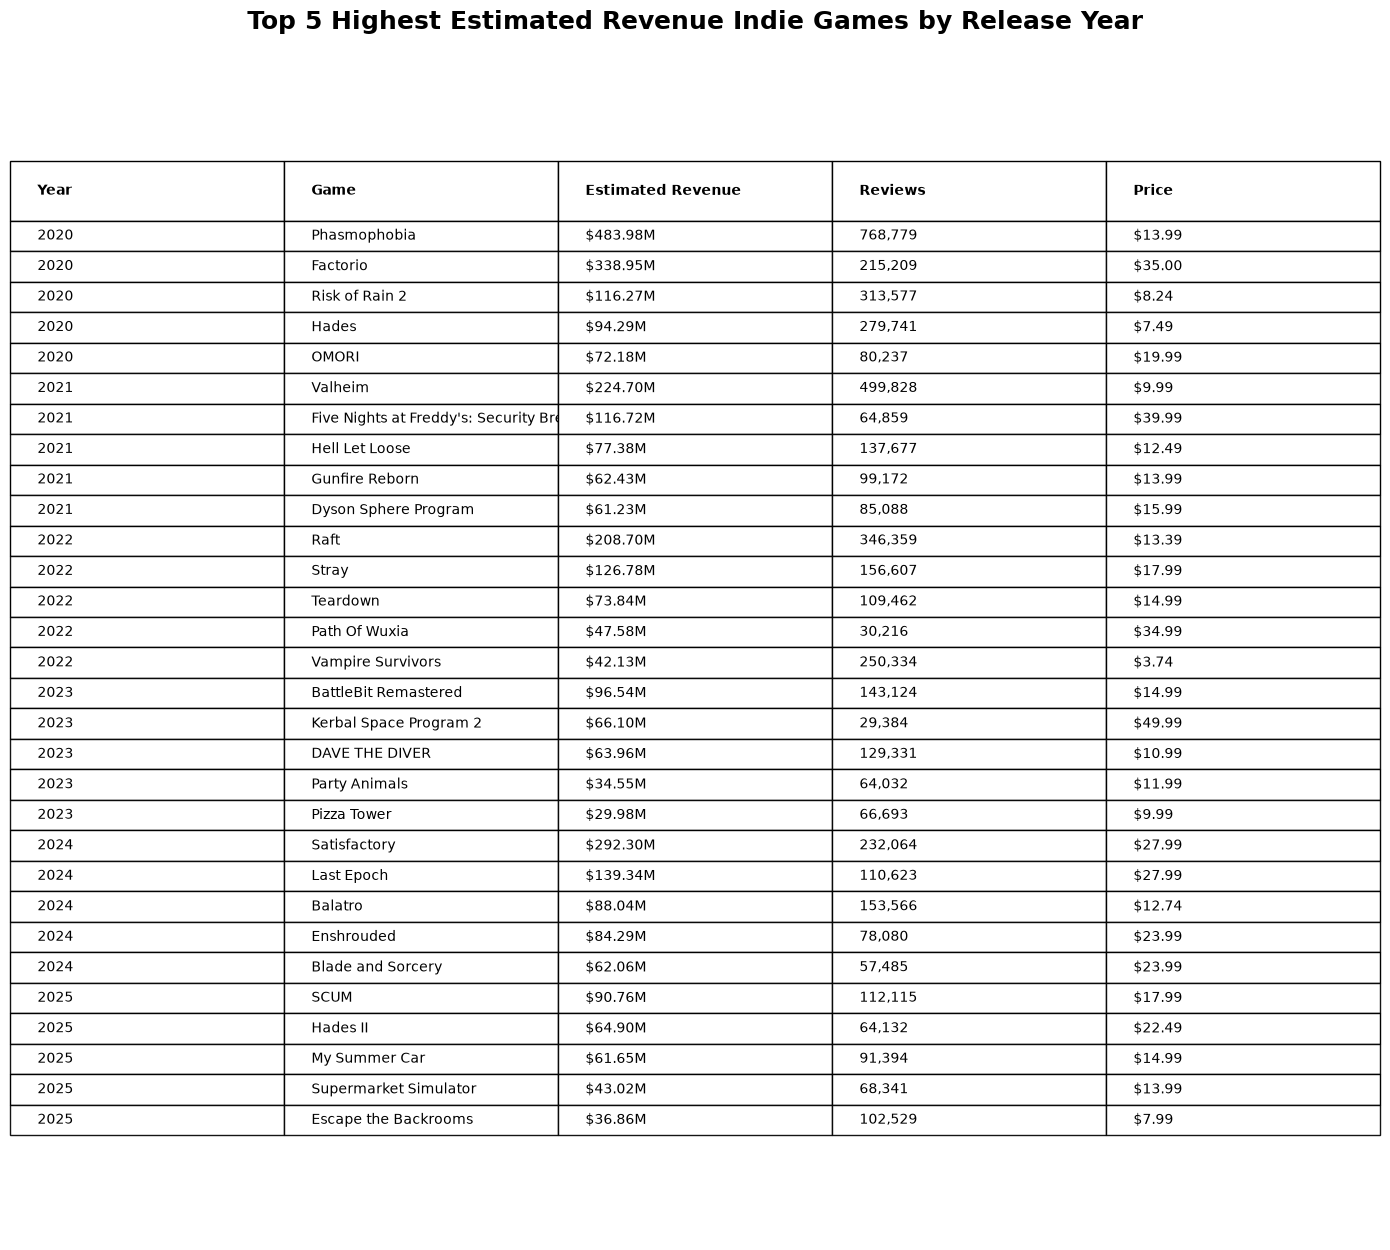

In [51]:
import matplotlib.pyplot as plt
import pandas as pd

START_YEAR = 2020
END_YEAR = 2025
TOP_N = 5

# Games tagged Indie
indie_games = df.loc[
    df["release_year"].between(START_YEAR, END_YEAR)
    & df["tag_list"].apply(lambda tags: "Indie" in tags)
    & df["estimated_revenue"].gt(0)
].copy()

# Top 5 per year
top_indie = (
    indie_games
    .sort_values(
        ["release_year", "estimated_revenue"],
        ascending=[True, False]
    )
    .groupby("release_year", group_keys=False)
    .head(TOP_N)
)

# Build display table
display_table = (
    top_indie[
        [
            "release_year",
            "name",
            "estimated_revenue",
            "total_reviews",
            "price"
        ]
    ]
    .copy()
)

display_table["Estimated Revenue"] = (
    display_table["estimated_revenue"]
    .map(lambda x: f"${x/1_000_000:,.2f}M")
)

display_table["Reviews"] = (
    display_table["total_reviews"]
    .map(lambda x: f"{x:,.0f}")
)

display_table["Price"] = (
    display_table["price"]
    .map(lambda x: f"${x:.2f}")
)

display_table = display_table.rename(columns={
    "release_year": "Year",
    "name": "Game"
})

display_table = display_table[
    [
        "Year",
        "Game",
        "Estimated Revenue",
        "Reviews",
        "Price"
    ]
]

# ---------------- Figure ----------------

fig_height = max(6, len(display_table) * 0.42)

fig, ax = plt.subplots(figsize=(14, fig_height))

ax.axis("off")

table = ax.table(
    cellText=display_table.values,
    colLabels=display_table.columns,
    cellLoc="left",
    colLoc="left",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

# Header styling
for (r, c), cell in table.get_celld().items():

    if r == 0:
        cell.set_text_props(weight="bold")
        cell.set_height(0.05)

    # Alternate row shading
    elif r % 2 == 0:
        cell.set_alpha(0.92)

plt.title(
    "Top 5 Highest Estimated Revenue Indie Games by Release Year",
    fontsize=18,
    weight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

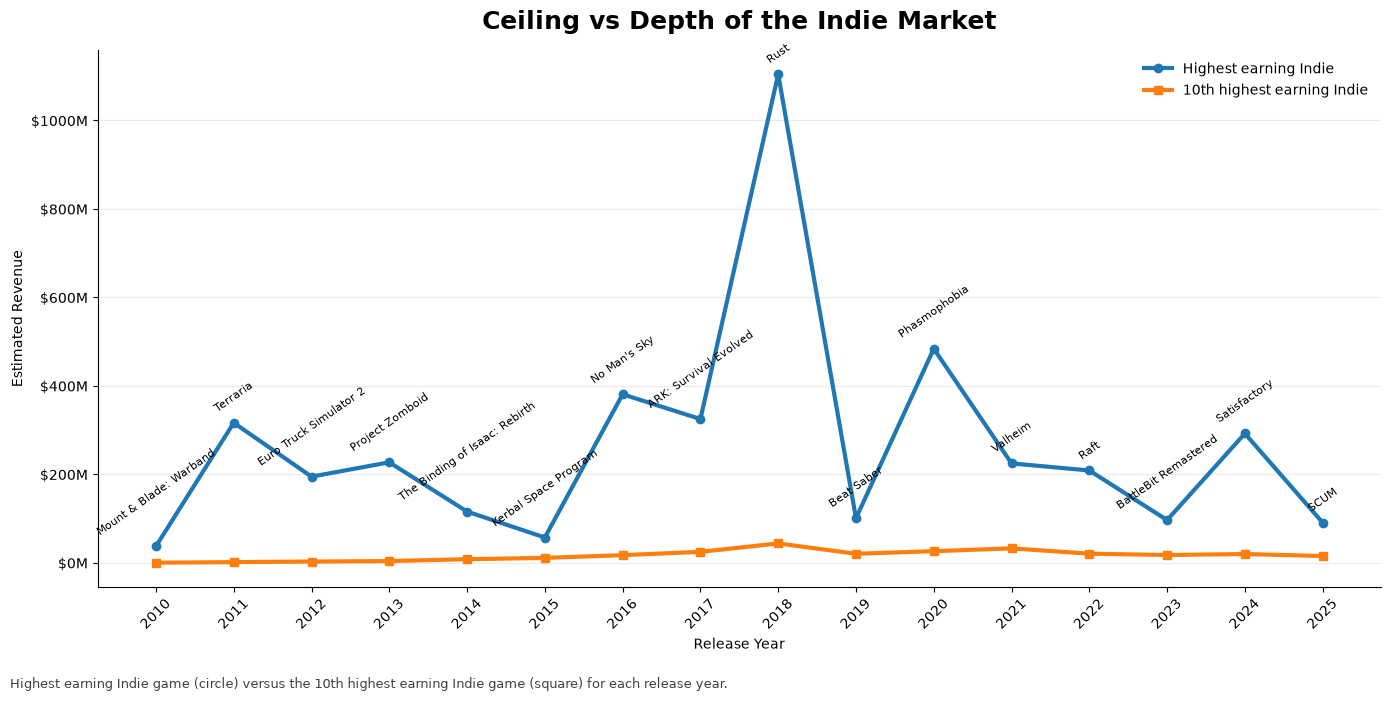

,release_year,top1_name,top1_revenue,top10_name,top10_revenue
0,2010,Mount & Blade: Warband,"$37,366,243",Shank,"$237,994"
1,2011,Terraria,"$316,497,162",Mount & Blade: With Fire & Sword,"$1,520,967"
2,2012,Euro Truck Simulator 2,"$194,775,568",Deadlight,"$2,807,427"
3,2013,Project Zomboid,"$227,199,311",Antichamber,"$3,843,173"
4,2014,The Binding of Isaac: Rebirth,"$115,749,711",Five Nights at Freddy's 2,"$8,160,706"
5,2015,Kerbal Space Program,"$57,165,677",Pillars of Eternity,"$11,081,408"
6,2016,No Man's Sky,"$380,927,854",Enter the Gungeon,"$17,287,802"
7,2017,ARK: Survival Evolved,"$324,962,158",Hellblade: Senua's Sacrifice,"$24,763,738"
8,2018,Rust,"$1,104,453,097",Kingdom Come: Deliverance,"$43,722,627"
9,2019,Beat Saber,"$100,692,625",Slay the Spire,"$20,424,138"


In [52]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

START_YEAR = 2010
END_YEAR = 2025

# Indie games only
indie_games = (
    df[
        df["release_year"].between(START_YEAR, END_YEAR)
        & df["tag_list"].apply(lambda tags: "Indie" in tags)
        & df["estimated_revenue"].gt(0)
    ]
    .sort_values(
        ["release_year", "estimated_revenue"],
        ascending=[True, False]
    )
    .copy()
)

# Rank games within each release year
indie_games["rank"] = (
    indie_games
    .groupby("release_year")
    .cumcount()
    + 1
)

# Highest earning
top1 = (
    indie_games[
        indie_games["rank"] == 1
    ][
        ["release_year", "name", "estimated_revenue"]
    ]
    .rename(columns={
        "name": "top1_name",
        "estimated_revenue": "top1_revenue"
    })
)

# 10th highest earning
top10 = (
    indie_games[
        indie_games["rank"] == 10
    ][
        ["release_year", "name", "estimated_revenue"]
    ]
    .rename(columns={
        "name": "top10_name",
        "estimated_revenue": "top10_revenue"
    })
)

plot_df = (
    top1
    .merge(
        top10,
        on="release_year",
        how="left"
    )
)

# ---------------- Plot ----------------

fig, ax = plt.subplots(figsize=(14,7))

ax.plot(
    plot_df["release_year"],
    plot_df["top1_revenue"],
    marker="o",
    linewidth=3,
    label="Highest earning Indie"
)

ax.plot(
    plot_df["release_year"],
    plot_df["top10_revenue"],
    marker="s",
    linewidth=3,
    label="10th highest earning Indie"
)

# Annotate top game names
for _, row in plot_df.iterrows():
    ax.annotate(
        row["top1_name"],
        xy=(row["release_year"], row["top1_revenue"]),
        xytext=(0,8),
        textcoords="offset points",
        ha="center",
        fontsize=8,
        rotation=35
    )

ax.set_title(
    "Ceiling vs Depth of the Indie Market",
    fontsize=18,
    weight="bold",
    pad=15
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Estimated Revenue")

ax.set_xticks(range(START_YEAR, END_YEAR + 1))
ax.tick_params(axis="x", rotation=45)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"${x/1_000_000:.0f}M"
    )
)

ax.grid(axis="y", alpha=0.25)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

fig.text(
    0.01,
    0.01,
    (
        "Highest earning Indie game (circle) versus the 10th highest earning "
        "Indie game (square) for each release year."
    ),
    fontsize=9,
    alpha=0.75
)

plt.tight_layout(rect=[0,0.04,1,1])
plt.show()

display(
    plot_df.style.format({
        "top1_revenue":"${:,.0f}",
        "top10_revenue":"${:,.0f}"
    })
)

In [53]:
START_YEAR = 2010
END_YEAR = 2025
TARGET_SHARE = 0.80

# Indie games only
indie_games = (
    df[
        df["release_year"].between(START_YEAR, END_YEAR)
        & df["tag_list"].apply(lambda tags: "Indie" in tags)
        & df["estimated_revenue"].gt(0)
    ]
    .copy()
)

results = []

for year, group in indie_games.groupby("release_year"):

    group = (
        group
        .sort_values(
            "estimated_revenue",
            ascending=False
        )
        .reset_index(drop=True)
    )

    total_revenue = group["estimated_revenue"].sum()

    group["cum_share"] = (
        group["estimated_revenue"].cumsum()
        / total_revenue
    )

    games_needed = (
        group["cum_share"]
        .ge(TARGET_SHARE)
        .idxmax()
        + 1
    )

    total_games = len(group)

    results.append({
        "release_year": year,
        "games": total_games,
        "games_needed": games_needed,
        "share_of_games": 100 * games_needed / total_games,
        "total_revenue": total_revenue
    })

concentration = pd.DataFrame(results)

display(
    concentration.style.format({
        "games":"{:,.0f}",
        "games_needed":"{:,.0f}",
        "share_of_games":"{:.2f}%",
        "total_revenue":"${:,.0f}"
    })
)

,release_year,games,games_needed,share_of_games,total_revenue
0,2010,71,2,2.82%,"$52,192,998"
1,2011,98,1,1.02%,"$366,159,839"
2,2012,155,5,3.23%,"$304,015,992"
3,2013,242,11,4.55%,"$423,652,046"
4,2014,806,42,5.21%,"$505,762,019"
5,2015,"1,650",57,3.45%,"$586,476,681"
6,2016,"2,566",18,0.70%,"$1,504,622,021"
7,2017,"3,664",23,0.63%,"$1,315,579,998"
8,2018,"4,742",13,0.27%,"$2,693,821,610"
9,2019,"4,266",57,1.34%,"$987,057,376"


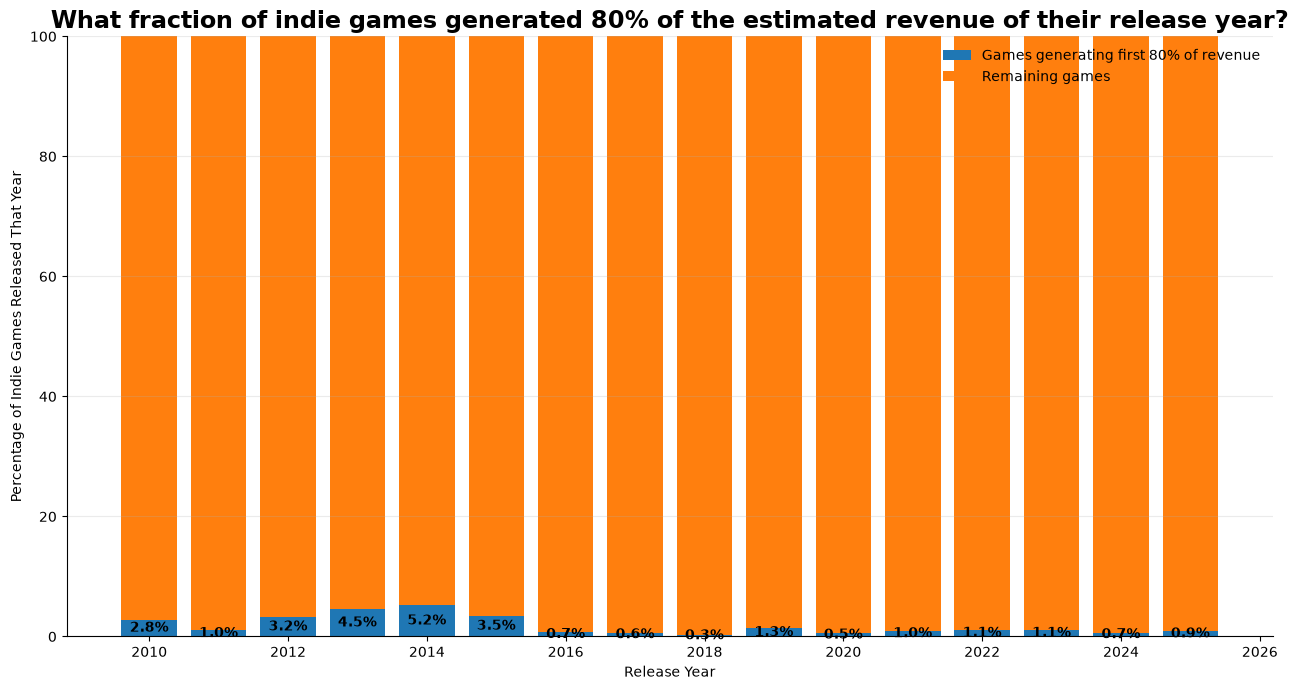

In [55]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(13,7))

# Bottom = games contributing to first 80%
ax.bar(
    concentration["release_year"],
    concentration["share_of_games"],
    label="Games generating first 80% of revenue"
)

# Remaining games
ax.bar(
    concentration["release_year"],
    100 - concentration["share_of_games"],
    bottom=concentration["share_of_games"],
    label="Remaining games"
)

# Label percentage
for _, row in concentration.iterrows():

    ax.text(
        row["release_year"],
        row["share_of_games"]/2,
        f'{row["share_of_games"]:.1f}%',
        ha="center",
        va="center",
        fontsize=10,
        weight="bold"
    )

ax.set_ylim(0,100)

ax.set_title(
    "What fraction of indie games generated 80% of the estimated revenue of their release year?",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel(
    "Percentage of Indie Games Released That Year"
)

ax.legend(frameon=False)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

In [56]:
START_YEAR = 2010
END_YEAR = 2025
TARGET_SHARE = 0.80

all_games = (
    df[
        df["release_year"].between(START_YEAR, END_YEAR)
        & df["estimated_revenue"].gt(0)
    ]
    .copy()
)

results = []

for year, group in all_games.groupby("release_year"):

    group = (
        group
        .sort_values(
            "estimated_revenue",
            ascending=False
        )
        .reset_index(drop=True)
    )

    total_revenue = group["estimated_revenue"].sum()

    group["cum_share"] = (
        group["estimated_revenue"].cumsum()
        / total_revenue
    )

    games_needed = (
        group["cum_share"]
        .ge(TARGET_SHARE)
        .idxmax()
        + 1
    )

    total_games = len(group)

    results.append({
        "release_year": year,
        "total_games": total_games,
        "games_needed": games_needed,
        "share_of_games": (
            100 * games_needed / total_games
        ),
        "total_revenue": total_revenue
    })

steam_concentration = pd.DataFrame(results)

display(
    steam_concentration.style.format({
        "total_games":"{:,.0f}",
        "games_needed":"{:,.0f}",
        "share_of_games":"{:.2f}%",
        "total_revenue":"${:,.0f}"
    })
)

,release_year,total_games,games_needed,share_of_games,total_revenue
0,2010,226,11,4.87%,"$456,083,328"
1,2011,232,8,3.45%,"$935,871,910"
2,2012,285,18,6.32%,"$616,476,686"
3,2013,398,24,6.03%,"$1,007,315,813"
4,2014,"1,387",58,4.18%,"$1,302,458,380"
5,2015,"2,220",36,1.62%,"$2,361,433,448"
6,2016,"3,532",28,0.79%,"$4,242,370,079"
7,2017,"4,932",64,1.30%,"$2,421,833,898"
8,2018,"6,021",33,0.55%,"$4,678,517,444"
9,2019,"5,571",55,0.99%,"$3,132,014,581"


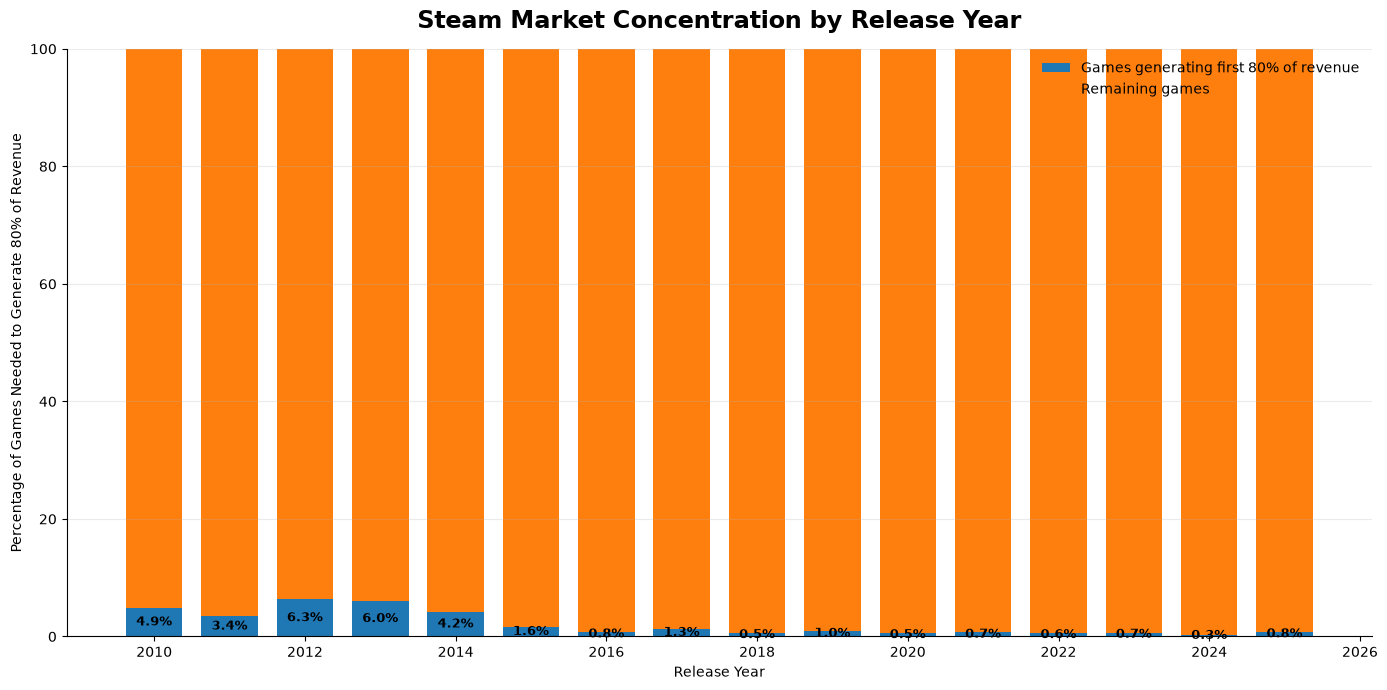

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(14,7))

ax.bar(
    steam_concentration["release_year"],
    steam_concentration["share_of_games"],
    width=0.75,
    label="Games generating first 80% of revenue"
)

ax.bar(
    steam_concentration["release_year"],
    100 - steam_concentration["share_of_games"],
    bottom=steam_concentration["share_of_games"],
    width=0.75,
    label="Remaining games"
)

for _, row in steam_concentration.iterrows():

    ax.text(
        row["release_year"],
        row["share_of_games"]/2,
        f'{row["share_of_games"]:.1f}%',
        ha="center",
        va="center",
        fontsize=9,
        weight="bold"
    )

ax.set_ylim(0,100)

ax.set_title(
    "Steam Market Concentration by Release Year",
    fontsize=17,
    weight="bold",
    pad=15
)

ax.set_xlabel("Release Year")

ax.set_ylabel(
    "Percentage of Games Needed to Generate 80% of Revenue"
)

ax.legend(frameon=False)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

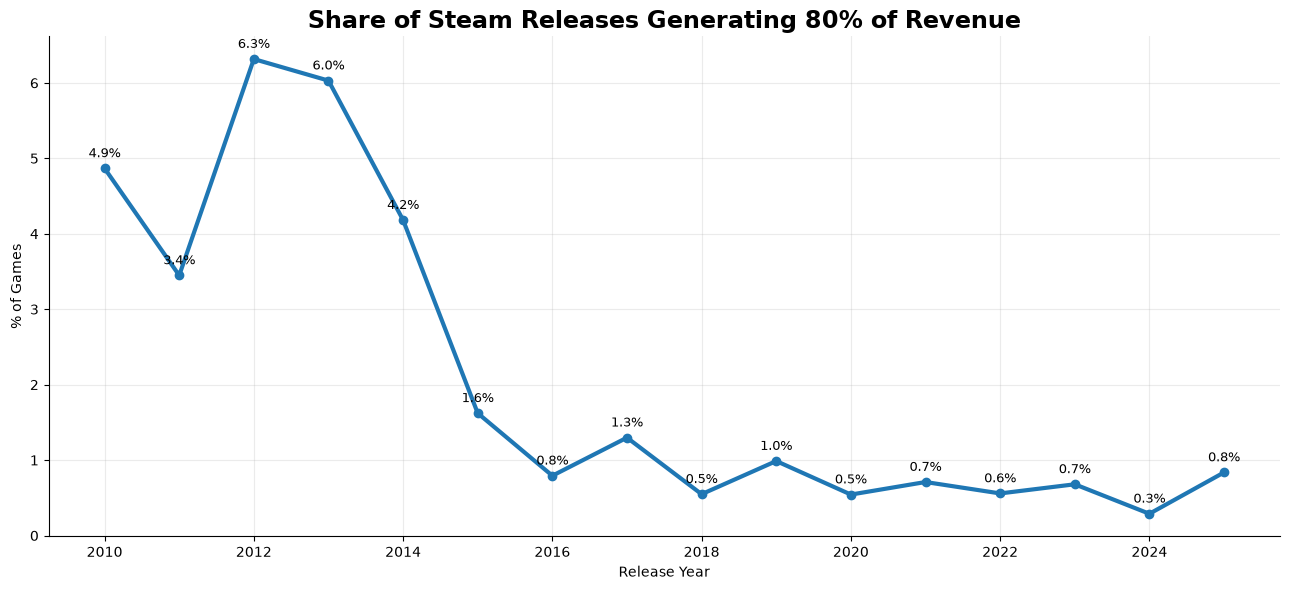

In [58]:
fig, ax = plt.subplots(figsize=(13,6))

ax.plot(
    steam_concentration["release_year"],
    steam_concentration["share_of_games"],
    marker="o",
    linewidth=3
)

for _, row in steam_concentration.iterrows():
    ax.annotate(
        f'{row["share_of_games"]:.1f}%',
        xy=(row["release_year"], row["share_of_games"]),
        xytext=(0,8),
        textcoords="offset points",
        ha="center",
        fontsize=9
    )

ax.set_title(
    "Share of Steam Releases Generating 80% of Revenue",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Release Year")

ax.set_ylabel("% of Games")

ax.grid(alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

In [59]:
import numpy as np
import pandas as pd

START_YEAR = 2010
END_YEAR = 2025

# Revenue percentiles we want to inspect
TOP_PERCENTAGES = [
    1,
    2,
    5,
    10,
    20,
    30,
    40,
    50,
    75,
    100
]

all_games = (
    df[
        df["release_year"].between(START_YEAR, END_YEAR)
        & df["estimated_revenue"].gt(0)
    ]
    .copy()
)

rows = []

for year, group in all_games.groupby("release_year"):

    group = (
        group
        .sort_values(
            "estimated_revenue",
            ascending=False
        )
        .reset_index(drop=True)
    )

    total_games = len(group)
    total_revenue = group["estimated_revenue"].sum()

    for pct in TOP_PERCENTAGES:

        games_to_take = max(
            1,
            int(np.ceil(total_games * pct / 100))
        )

        revenue_share = (
            group
            .head(games_to_take)["estimated_revenue"]
            .sum()
            / total_revenue
        )

        rows.append({
            "release_year": year,
            "top_percent": pct,
            "games_taken": games_to_take,
            "revenue_share": revenue_share * 100
        })

concentration_curve = pd.DataFrame(rows)

display(concentration_curve.head())

,release_year,top_percent,games_taken,revenue_share
0,2010,1,3,44.846993
1,2010,2,5,60.973573
2,2010,5,12,82.544471
3,2010,10,23,91.304625
4,2010,20,46,97.728410


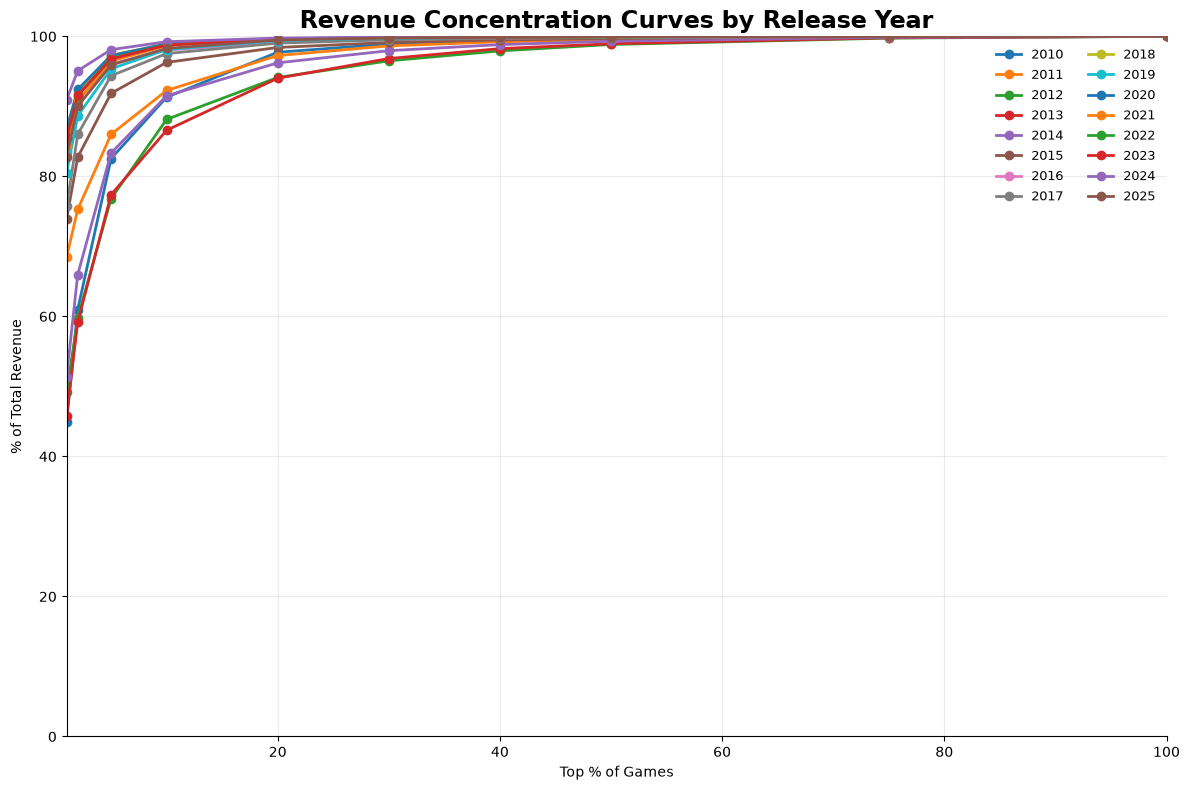

In [60]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,8))

for year, group in concentration_curve.groupby("release_year"):

    ax.plot(
        group["top_percent"],
        group["revenue_share"],
        marker="o",
        linewidth=2,
        label=str(year)
    )

ax.set_title(
    "Revenue Concentration Curves by Release Year",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel(
    "Top % of Games"
)

ax.set_ylabel(
    "% of Total Revenue"
)

ax.set_xlim(1,100)
ax.set_ylim(0,100)

ax.grid(alpha=0.25)

ax.legend(
    ncol=2,
    fontsize=9,
    frameon=False
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

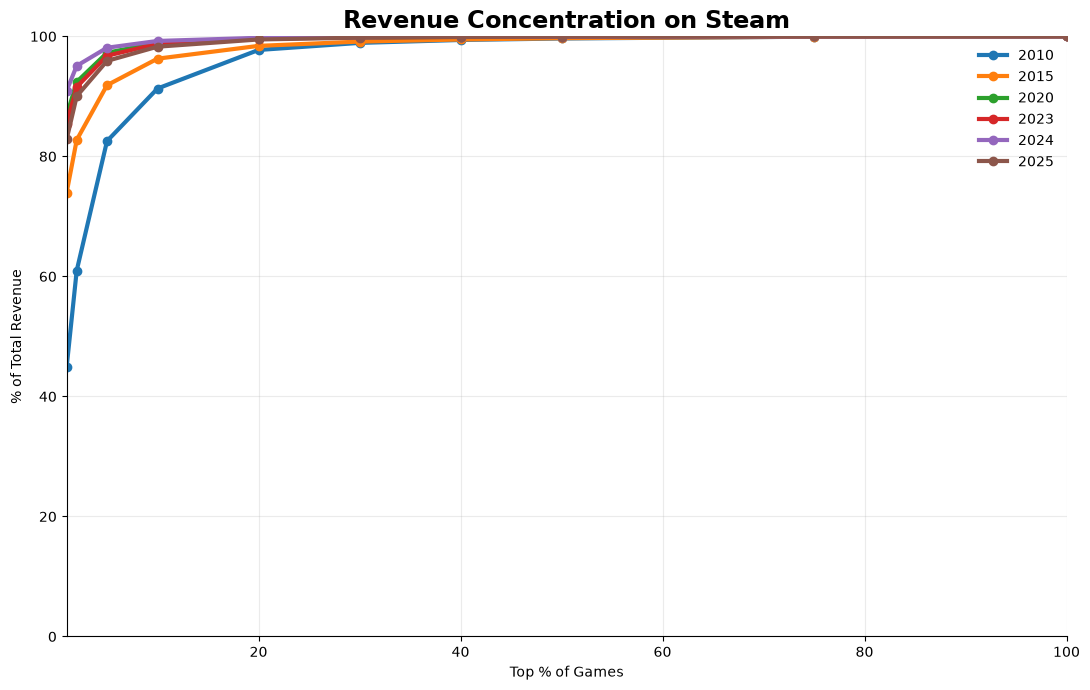

In [61]:
YEARS_TO_SHOW = [
    2010,
    2015,
    2020,
    2023,
    2024,
    2025
]

fig, ax = plt.subplots(figsize=(11,7))

for year in YEARS_TO_SHOW:

    group = concentration_curve[
        concentration_curve["release_year"] == year
    ]

    ax.plot(
        group["top_percent"],
        group["revenue_share"],
        marker="o",
        linewidth=3,
        label=str(year)
    )

ax.set_title(
    "Revenue Concentration on Steam",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Top % of Games")
ax.set_ylabel("% of Total Revenue")

ax.set_xlim(1,100)
ax.set_ylim(0,100)

ax.grid(alpha=0.25)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

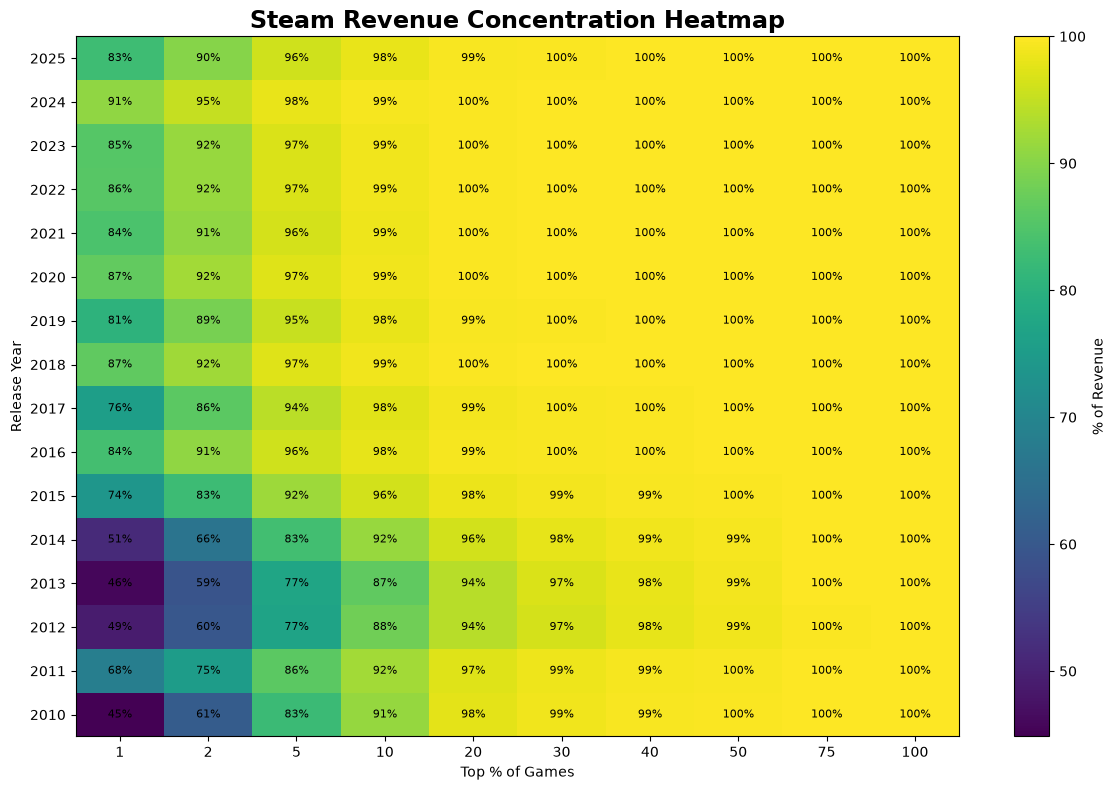

In [62]:
import matplotlib.pyplot as plt

heatmap = (
    concentration_curve
    .pivot(
        index="release_year",
        columns="top_percent",
        values="revenue_share"
    )
)

fig, ax = plt.subplots(figsize=(12,8))

im = ax.imshow(
    heatmap,
    aspect="auto",
    origin="lower"
)

ax.set_xticks(range(len(heatmap.columns)))
ax.set_xticklabels(heatmap.columns)

ax.set_yticks(range(len(heatmap.index)))
ax.set_yticklabels(heatmap.index)

ax.set_xlabel(
    "Top % of Games"
)

ax.set_ylabel(
    "Release Year"
)

ax.set_title(
    "Steam Revenue Concentration Heatmap",
    fontsize=17,
    weight="bold"
)

for i in range(len(heatmap.index)):
    for j in range(len(heatmap.columns)):

        ax.text(
            j,
            i,
            f"{heatmap.iloc[i,j]:.0f}%",
            ha="center",
            va="center",
            fontsize=8
        )

plt.colorbar(
    im,
    label="% of Revenue"
)

plt.tight_layout()

plt.show()

In [63]:
import numpy as np

revenue_bins = [
    0,
    10_000,
    50_000,
    150_000,
    800_000,
    5_000_000,
    20_000_000,
    np.inf
]

revenue_labels = [
    "<$10K",
    "$10K–50K",
    "$50K–150K",
    "$150K–800K",
    "$800K–5M",
    "$5M–20M",
    ">$20M"
]

analysis_games = (
    df[
        df["release_year"].between(2010, 2025)
        & df["estimated_revenue"].gt(0)
    ]
    .copy()
)

analysis_games["revenue_band"] = pd.cut(
    analysis_games["estimated_revenue"],
    bins=revenue_bins,
    labels=revenue_labels,
    include_lowest=True
)

In [64]:
games_by_band = (
    analysis_games
    .groupby(
        ["release_year","revenue_band"],
        observed=True
    )
    .size()
    .reset_index(name="games")
)

games_by_band.head()

,release_year,revenue_band,games
0,2010,<$10K,53
1,2010,$10K–50K,71
2,2010,$50K–150K,36
3,2010,$150K–800K,28
4,2010,$800K–5M,27


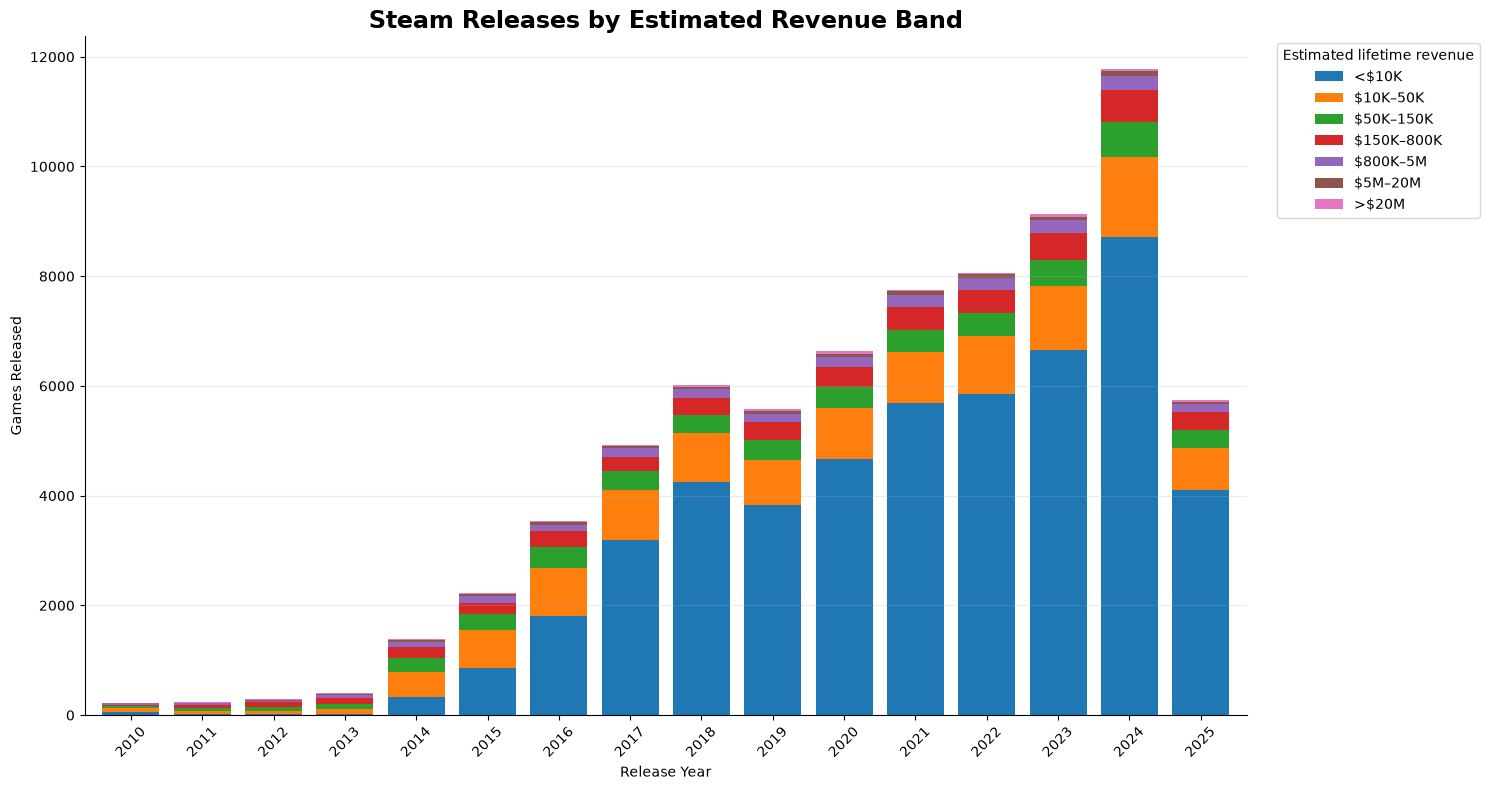

In [65]:
pivot = (
    games_by_band
    .pivot(
        index="release_year",
        columns="revenue_band",
        values="games"
    )
    .fillna(0)
)

fig, ax = plt.subplots(figsize=(15,8))

pivot.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8
)

ax.set_title(
    "Steam Releases by Estimated Revenue Band",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Release Year")
ax.set_ylabel("Games Released")

ax.tick_params(axis="x", rotation=45)

ax.grid(axis="y", alpha=0.25)

ax.legend(
    title="Estimated lifetime revenue",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

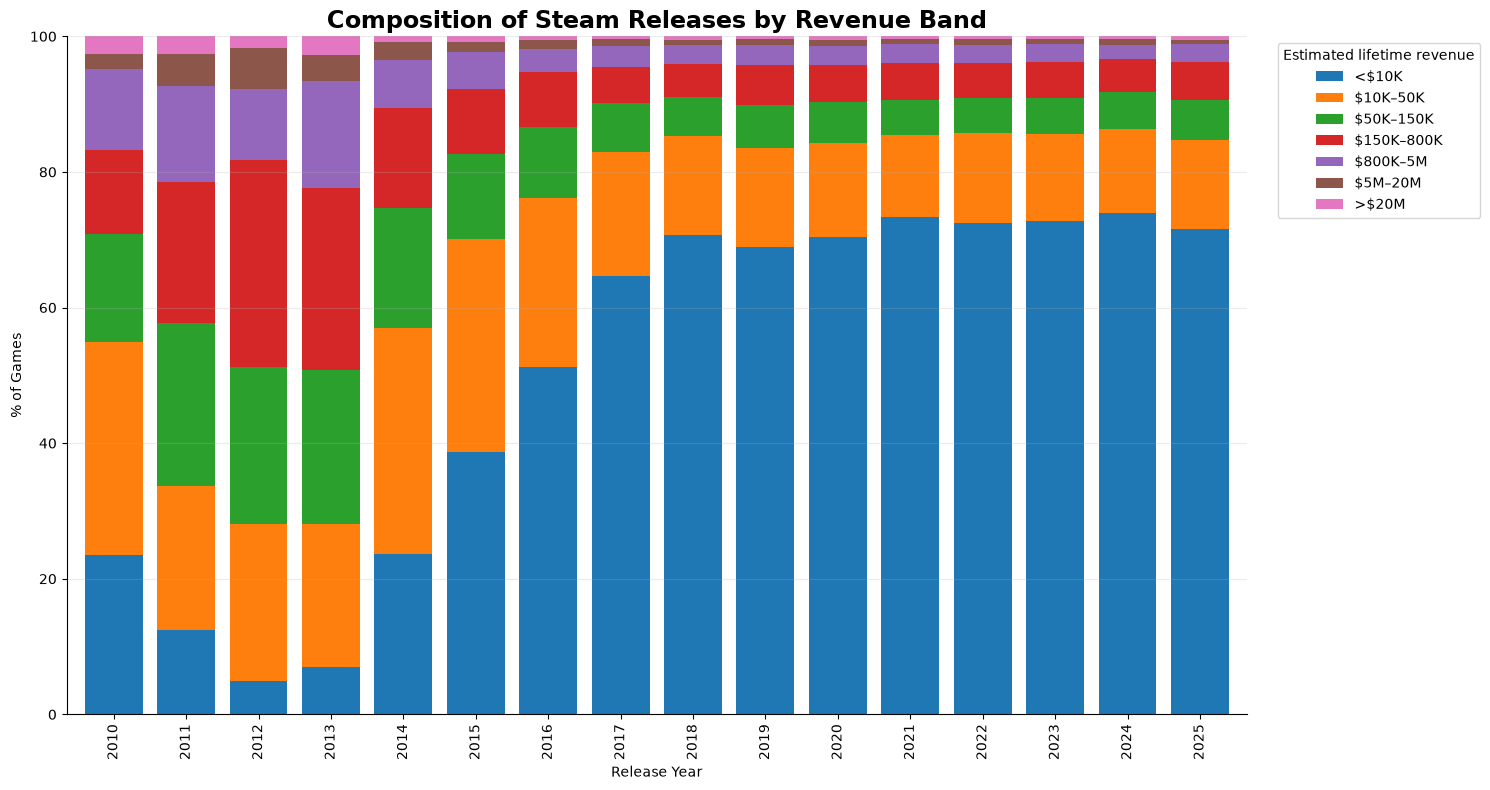

In [66]:
share = pivot.div(
    pivot.sum(axis=1),
    axis=0
) * 100

fig, ax = plt.subplots(figsize=(15,8))

share.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8
)

ax.set_ylim(0,100)

ax.set_title(
    "Composition of Steam Releases by Revenue Band",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Release Year")

ax.set_ylabel("% of Games")

ax.legend(
    title="Estimated lifetime revenue",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

In [67]:
revenue_by_band = (
    analysis_games
    .groupby(
        ["release_year","revenue_band"],
        observed=True
    )["estimated_revenue"]
    .sum()
    .reset_index()
)

revenue_pivot = (
    revenue_by_band
    .pivot(
        index="release_year",
        columns="revenue_band",
        values="estimated_revenue"
    )
    .fillna(0)
)

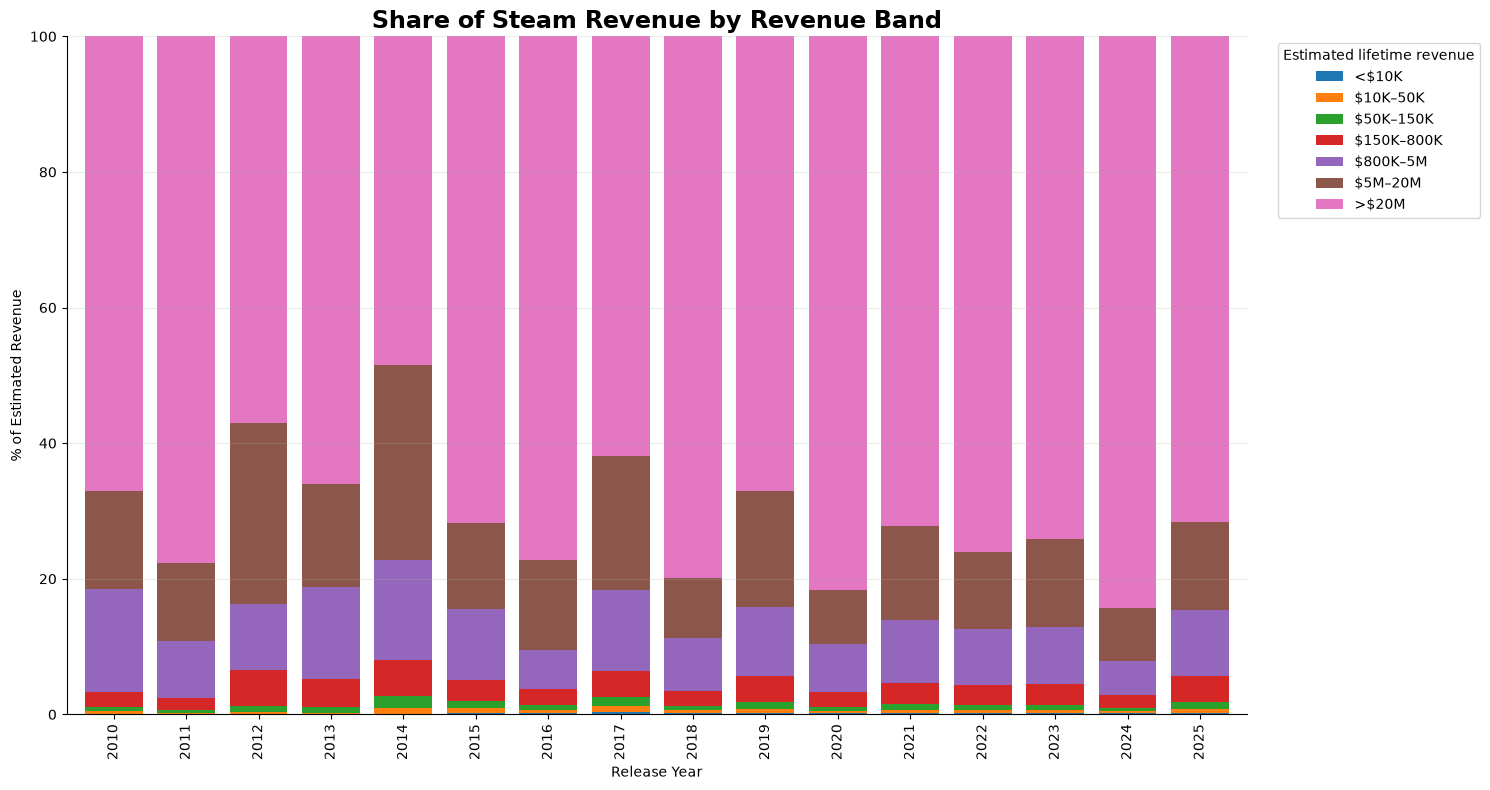

In [68]:
revenue_share = (
    revenue_pivot
    .div(
        revenue_pivot.sum(axis=1),
        axis=0
    )
    *100
)

fig, ax = plt.subplots(figsize=(15,8))

revenue_share.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    width=0.8
)

ax.set_ylim(0,100)

ax.set_title(
    "Share of Steam Revenue by Revenue Band",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Release Year")

ax.set_ylabel("% of Estimated Revenue")

ax.legend(
    title="Estimated lifetime revenue",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

ax.grid(axis="y", alpha=0.25)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

In [69]:
middle = (
    analysis_games[
        analysis_games["revenue_band"]=="$150K–800K"
    ]
    .groupby("release_year")
    .agg(
        games=("appid","count"),
        revenue=("estimated_revenue","sum")
    )
)

total = (
    analysis_games
    .groupby("release_year")
    .agg(
        total_games=("appid","count"),
        total_revenue=("estimated_revenue","sum")
    )
)

summary = (
    middle
    .join(total)
)

summary["share_games"] = (
    100
    *summary["games"]
    /summary["total_games"]
)

summary["share_revenue"] = (
    100
    *summary["revenue"]
    /summary["total_revenue"]
)

display(summary)

,games,revenue,total_games,total_revenue,share_games,share_revenue
release_year,,,,,,
2010,28,9.680957e+06,226,4.560833e+08,12.389381,2.122629
2011,48,1.644215e+07,232,9.358719e+08,20.689655,1.756880
2012,87,3.222759e+07,285,6.164767e+08,30.526316,5.227707
2013,107,4.092411e+07,398,1.007316e+09,26.884422,4.062690
2014,204,6.878439e+07,1387,1.302458e+09,14.708003,5.281120
2015,211,7.334578e+07,2220,2.361433e+09,9.504505,3.105986
2016,288,1.012996e+08,3532,4.242370e+09,8.154020,2.387807
2017,263,9.244128e+07,4932,2.421834e+09,5.332522,3.816995
2018,293,1.024453e+08,6021,4.678517e+09,4.866301,2.189695


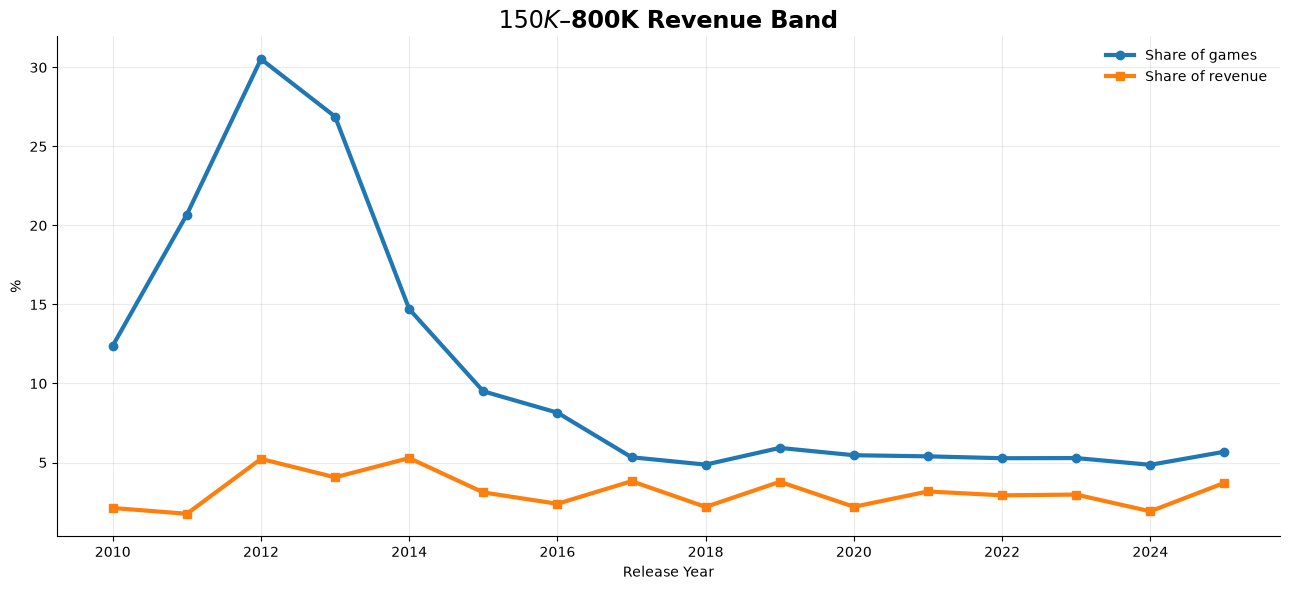

In [70]:
fig, ax = plt.subplots(figsize=(13,6))

ax.plot(
    summary.index,
    summary["share_games"],
    marker="o",
    linewidth=3,
    label="Share of games"
)

ax.plot(
    summary.index,
    summary["share_revenue"],
    marker="s",
    linewidth=3,
    label="Share of revenue"
)

ax.set_title(
    "$150K–$800K Revenue Band",
    fontsize=17,
    weight="bold"
)

ax.set_xlabel("Release Year")

ax.set_ylabel("%")

ax.grid(alpha=0.25)

ax.legend(frameon=False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.show()

In [71]:
START_YEAR = 2022
END_YEAR = 2025

tag_competitiveness = (
    tag_revenue_rows[
        tag_revenue_rows["release_year"].between(
            START_YEAR,
            END_YEAR
        )
    ]
    .groupby("tag")
    .agg(
        games=("appid","nunique"),
        total_revenue=("revenue_per_tag","sum")
    )
)

tag_competitiveness["revenue_per_game"] = (
    tag_competitiveness["total_revenue"]
    / tag_competitiveness["games"]
)

tag_competitiveness = (
    tag_competitiveness[
        tag_competitiveness["games"]>=20
    ]
    .sort_values(
        "revenue_per_game",
        ascending=False
    )
)

display(tag_competitiveness.head(30))

,games,total_revenue,revenue_per_game
tag,,,
Design & Illustration,37,1.339363e+06,36198.990294
Software,22,7.285223e+05,33114.651050
VR,69,1.676444e+06,24296.284975
Dragons,20,4.760052e+05,23800.258602
Great Soundtrack,40,9.504765e+05,23761.912483
LGBTQ+,60,1.396778e+06,23279.641612
Grand Strategy,32,7.384134e+05,23075.419169
Mechs,34,7.647449e+05,22492.497936
Driving,62,1.372721e+06,22140.665092


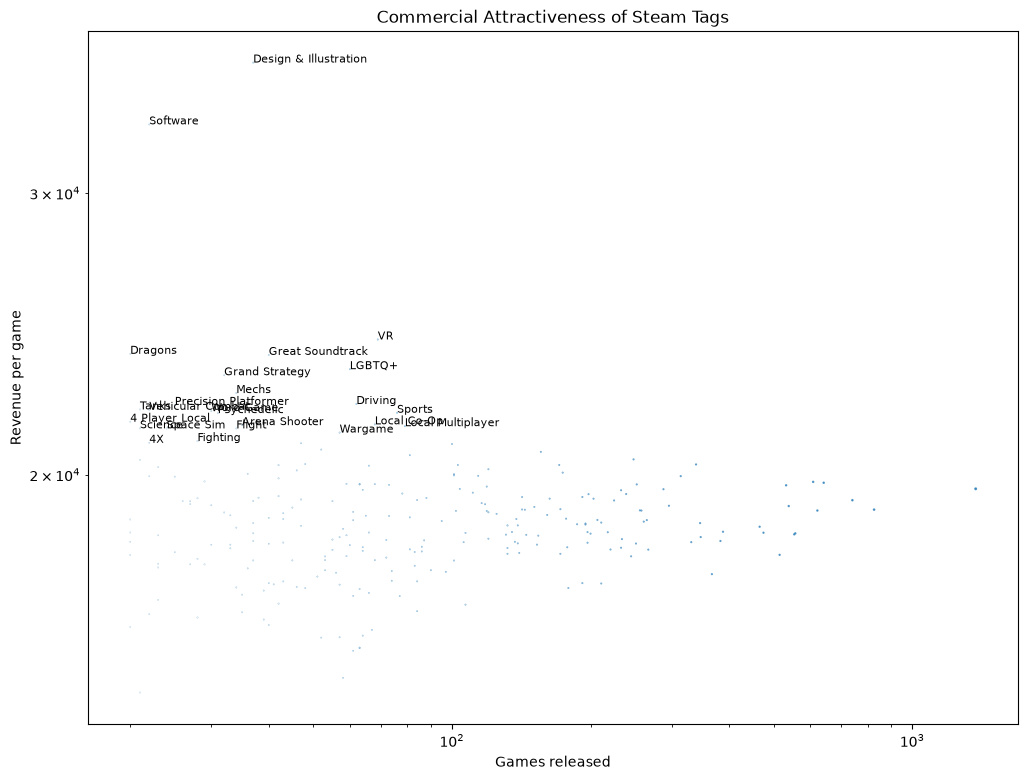

In [72]:
fig, ax = plt.subplots(figsize=(12,9))

ax.scatter(
    tag_competitiveness["games"],
    tag_competitiveness["revenue_per_game"],
    s=tag_competitiveness["total_revenue"]/2e7,
    alpha=0.7
)

# Label top tags
for tag, row in (
    tag_competitiveness
    .head(25)
    .iterrows()
):

    ax.text(
        row["games"],
        row["revenue_per_game"],
        tag,
        fontsize=8
    )

ax.set_xscale("log")
ax.set_yscale("log")

ax.set_xlabel("Games released")
ax.set_ylabel("Revenue per game")

ax.set_title(
    "Commercial Attractiveness of Steam Tags"
)

plt.show()

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

ModuleNotFoundError: No module named 'networkx'